# Đồ án: Hệ thống gợi ý phim theo cá nhân hoá

**Môn:** Học máy và khai phá dữ liệu  
**Bài toán:** Xây dựng hệ thống gợi ý phim cá nhân hoá dựa trên dữ liệu MovieLens 1M.

Notebook được trình bày theo cấu trúc thống nhất:

> **Nội dung và mục đích của bước xử lý → Code thực hiện → Kết quả đầu ra**

Nhờ đó, phần thuyết minh không còn nằm tách rời khỏi code. Mỗi đoạn nội dung được đặt ngay trước cell code tương ứng để thuận tiện khi học, thuyết trình và viết báo cáo.

## Thông tin nhóm

| STT | Thành viên  | Nhiệm vụ | Mức độ đóng góp |
| --- | ---------------------- | ----------------------------------- | ------ |
| 1   | **Chu Thị Minh Hạnh** | Cài đặt, dữ liệu, EDA, chia dữ liệu, mapping và Hybrid Recommendation | 25%             |
| 2   | **Nguyễn Quốc Tuấn** | Mean Baseline, Popularity-based, Content-based và đánh giá Top-N | 25%             |
| 3   | **Nguyễn Hà Trung Nam** | SVD, Neural Collaborative Filtering, tổng hợp kết quả và lưu model | 25%   |
| 4   | **Phạm Ngọc Thành** | Gợi ý phim tương tự, demo, dự đoán cụ thể, xuất CSV và load model | 25%  |

## 1. Tổng quan đề tài

Trong thời đại số, lượng nội dung phim trên các nền tảng trực tuyến ngày càng lớn. Người dùng thường gặp khó khăn khi lựa chọn bộ phim phù hợp với sở thích cá nhân. Vì vậy, hệ thống gợi ý phim đóng vai trò quan trọng trong việc hỗ trợ người dùng khám phá nội dung phù hợp, đồng thời nâng cao trải nghiệm sử dụng hệ thống.

Đề tài **“Hệ thống gợi ý phim theo cá nhân hoá”** tập trung xây dựng mô hình học máy có khả năng phân tích dữ liệu đánh giá phim của người dùng, từ đó dự đoán mức độ yêu thích và đề xuất danh sách phim phù hợp cho từng người dùng.

Bài toán này thuộc nhóm **Recommendation System**, một ứng dụng phổ biến của học máy và khai phá dữ liệu trong thương mại điện tử, mạng xã hội, nền tảng xem phim, nghe nhạc và học trực tuyến.


## 2. Mục tiêu đề tài

Mục tiêu chính của đề tài là xây dựng một hệ thống có khả năng gợi ý phim cá nhân hoá dựa trên lịch sử đánh giá của người dùng.

Các mục tiêu cụ thể:

| Mục tiêu | Nội dung |
|---|---|
| Phân tích dữ liệu | Khám phá đặc điểm người dùng, phim, rating và thể loại phim |
| Tiền xử lý dữ liệu | Làm sạch, mã hoá, xác định cột đầu vào, nhãn mục tiêu và metadata |
| Xây dựng mô hình gợi ý | Triển khai 5 mô hình: Popularity-based, Content-based, Matrix Factorization/SVD, Neural Collaborative Filtering và Hybrid |
| Đánh giá mô hình | Sử dụng loss/val_loss, MAE, RMSE, Precision@K, Recall@K và NDCG@K |
| Demo hệ thống | Cho phép nhập UserID để nhận danh sách phim được gợi ý |

Kết quả mong muốn là hệ thống có thể đưa ra danh sách Top-N phim phù hợp với từng người dùng thay vì chỉ gợi ý các phim phổ biến chung chung.

Trong phạm vi đề tài, nhóm không triển khai riêng User-based hoặc Item-based Collaborative Filtering để tránh mở rộng quá nhiều. Mô hình **SVD/Matrix Factorization** được sử dụng như đại diện chính cho hướng collaborative filtering vì khai thác được quan hệ tiềm ẩn giữa người dùng và phim.


### Yêu cầu về đầu vào và đặc trưng dự đoán

Notebook phải phân biệt rõ bốn khái niệm:

- **Cột dữ liệu gốc:** các cột đọc trực tiếp từ `ratings.dat`, `movies.dat`, `users.dat`.
- **Đặc trưng đầu vào (`X`):** thông tin mô hình thật sự nhận để tính điểm.
- **Nhãn mục tiêu (`y`):** giá trị mô hình cần học để dự đoán, trong bài toán rating là `Rating`.
- **Metadata hiển thị:** tên phim, thể loại dạng chuỗi và các thông tin dùng để giải thích kết quả, nhưng không nhất thiết đi vào mô hình.


## 3. Bài toán nghiên cứu

Đề tài giải quyết hai bài toán chính:

### 3.1. Dự đoán rating

Dự đoán người dùng sẽ đánh giá một bộ phim bao nhiêu điểm. Ở thời điểm suy luận, đầu vào trực tiếp là cặp `UserID` và `MovieID`; `Rating` thật chỉ tồn tại trong dữ liệu huấn luyện/đánh giá và đóng vai trò nhãn mục tiêu.

Ví dụ: với UserID = 15 và MovieID = 2571, hệ thống dự đoán người dùng có thể chấm phim này 4.6/5 điểm.

### 3.2. Gợi ý Top-N phim

Với mỗi người dùng, hệ thống nhận `UserID`, chấm điểm các `MovieID` ứng viên chưa xem và trả về danh sách N phim phù hợp nhất.

Ví dụ:

| Thứ hạng | Phim gợi ý | Điểm dự đoán |
|---:|---|---:|
| 1 | The Matrix | 4.85 |
| 2 | Star Wars | 4.78 |
| 3 | Terminator 2 | 4.70 |

Bản chất bài toán là khai phá sở thích cá nhân từ lịch sử đánh giá và hành vi của cộng đồng người dùng.


## 4. Quy trình thực hiện

Quy trình xây dựng hệ thống gồm các bước:

1. Thu thập và đọc dữ liệu.
2. Kiểm tra cấu trúc dữ liệu và xác định cột nào là đặc trưng, nhãn, cột chia dữ liệu hoặc metadata.
3. Phân tích khám phá dữ liệu.
4. Tiền xử lý dữ liệu.
5. Chia tập train/validation/test theo thời gian.
6. Xây dựng các mô hình gợi ý.
7. Đánh giá mô hình.
8. Xây dựng hàm demo gợi ý phim theo người dùng.

Quy trình này giúp đảm bảo mô hình không chỉ chạy được mà còn có cơ sở phân tích rõ ràng và có thể giải thích kết quả.


# PHẦN TRIỂN KHAI TRÊN GOOGLE COLAB


## 1. Cài đặt và import thư viện

### Mục đích

Bước đầu tiên chuẩn bị các thư viện cần thiết cho toàn bộ quy trình xử lý dữ liệu, xây dựng mô hình và đánh giá hệ thống gợi ý.

### Các thư viện được sử dụng

| Thư viện | Vai trò |
|---|---|
| `os`, `zipfile`, `urllib.request` | Tạo thư mục, tải và giải nén dữ liệu |
| `re` | Xử lý chuỗi và biểu thức chính quy |
| `numpy` | Tính toán ma trận và vector |
| `pandas` | Đọc, làm sạch, gộp và phân tích dữ liệu |
| `matplotlib` | Vẽ biểu đồ EDA và so sánh mô hình |
| `scipy.sparse` | Tạo ma trận thưa user–movie |
| `scipy.sparse.linalg.svds` | Phân rã ma trận bằng SVD |
| `sklearn.metrics` | Tính MAE và RMSE |
| `cosine_similarity` | Đo độ tương đồng cho Content-based |
| `tensorflow.keras` | Xây dựng Neural Collaborative Filtering bằng Embedding và mạng Dense |

### Kết quả mong đợi

Sau khi chạy cell, các thư viện được nạp thành công và notebook sẵn sàng thực hiện các bước tiếp theo. Google Colab thường đã cài sẵn TensorFlow nên không cần cài lại gói nặng này.


In [ ]:
# 1. Cài đặt và import thư viện

!pip -q install pandas numpy scikit-learn scipy matplotlib

import os
import random
import re
import urllib.request
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

print('Random seed:', SEED)


Random seed: 42


## 2. Dữ liệu sử dụng và cách tải dữ liệu

Đề tài sử dụng bộ dữ liệu **MovieLens 1M** của GroupLens. Bộ dữ liệu chứa khoảng một triệu lượt đánh giá, hơn 6.000 người dùng và gần 4.000 bộ phim.

### Các file và cột dữ liệu gốc

| File | Cột | Ý nghĩa | Vai trò trong notebook hiện tại |
|---|---|---|---|
| `ratings.dat` | `UserID` | Mã người dùng | Đầu vào định danh cho Baseline, Content profile, SVD, Neural CF và Hybrid |
| `ratings.dat` | `MovieID` | Mã phim | Đầu vào định danh, khóa nối dữ liệu và tập ứng viên gợi ý |
| `ratings.dat` | `Rating` | Điểm đánh giá từ 1 đến 5 | Nhãn mục tiêu của dự đoán rating; đồng thời dùng tạo profile, popularity và relevant item |
| `ratings.dat` | `Timestamp` | Thời điểm đánh giá | Chỉ dùng để chia train/validation/test theo thời gian, không đưa vào mô hình dự đoán |
| `movies.dat` | `MovieID` | Mã phim | Khóa nối với bảng rating |
| `movies.dat` | `Title` | Tên phim kèm năm | Metadata để hiển thị; dùng tách `Year` và `CleanTitle` |
| `movies.dat` | `Genres` | Chuỗi thể loại phân cách bằng `|` | Được one-hot thành các đặc trưng nội dung cho Content-based và Hybrid |
| `users.dat` | `UserID` | Mã người dùng | Khóa định danh |
| `users.dat` | `Gender` | Giới tính mã hóa | Hiện chỉ được đọc để khảo sát/mở rộng, chưa dùng dự đoán |
| `users.dat` | `Age` | Nhóm tuổi mã hóa | Hiện chưa dùng dự đoán |
| `users.dat` | `Occupation` | Mã nghề nghiệp | Hiện chưa dùng dự đoán |
| `users.dat` | `ZipCode` | Mã bưu chính | Hiện chưa dùng dự đoán |

### Cách cell code hoạt động

1. Tạo thư mục `/content/ml-1m`.
2. Kiểm tra ba file dữ liệu đã tồn tại hay chưa.
3. Nếu thiếu dữ liệu, tự động tải file `ml-1m.zip`.
4. Giải nén dữ liệu vào thư mục `/content`.
5. In danh sách file để kiểm tra.

### Kết quả mong đợi

Thư mục `/content/ml-1m` chứa đủ ba file `ratings.dat`, `movies.dat` và `users.dat`.

> **Lưu ý:** Có cột trong dữ liệu không đồng nghĩa cột đó được dùng làm đặc trưng. Notebook hiện tại không đưa `Gender`, `Age`, `Occupation`, `ZipCode`, `Title`, `CleanTitle`, `Year` hoặc `Timestamp` trực tiếp vào mô hình dự đoán.


In [ ]:
# 2. Tải hoặc upload dữ liệu MovieLens 1M
# Cách 1: Nếu bạn đã có file users.dat, movies.dat, ratings.dat, upload thủ công vào Colab.
# Cách 2: Nếu chưa có, chạy cell này để tải MovieLens 1M.

DATA_DIR = '/content/ml-1m'
os.makedirs(DATA_DIR, exist_ok=True)

ratings_path = os.path.join(DATA_DIR, 'ratings.dat')
movies_path = os.path.join(DATA_DIR, 'movies.dat')
users_path = os.path.join(DATA_DIR, 'users.dat')

if not (os.path.exists(ratings_path) and os.path.exists(movies_path) and os.path.exists(users_path)):
    print('Chưa thấy đủ file trong /content/ml-1m, đang tải MovieLens 1M...')
    url = 'https://files.grouplens.org/datasets/movielens/ml-1m.zip'
    zip_path = '/content/ml-1m.zip'
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content')
else:
    print('Đã có đủ dữ liệu.')

print(os.listdir(DATA_DIR)[:10])


Chưa thấy đủ file trong /content/ml-1m, đang tải MovieLens 1M...
['ratings.dat', 'README', 'movies.dat', 'users.dat']


## 3. Đọc dữ liệu vào DataFrame và xác định vai trò các cột

### Mục đích

Chuyển ba file văn bản của MovieLens thành các bảng `pandas DataFrame`, kiểm tra cấu trúc và xác định rõ cột nào được dùng trong từng bước của pipeline.

### Điểm cần lưu ý

- Dữ liệu MovieLens 1M dùng dấu phân cách `::`, không phải dấu phẩy.
- Tham số `engine='python'` được dùng vì dấu phân cách có nhiều ký tự.
- File không có dòng tiêu đề nên phải khai báo tên cột bằng `names`.
- `encoding='latin-1'` giúp đọc đúng tên phim có ký tự đặc biệt.

### Phân biệt đầu vào, nhãn và metadata

| Nhóm | Cột/biến | Cách sử dụng |
|---|---|---|
| Định danh đầu vào | `UserID`, `MovieID` | Được ánh xạ thành index để tạo ma trận hoặc Embedding |
| Nhãn mục tiêu | `Rating` | Giá trị thật cần dự đoán; với Neural CF được chuẩn hóa thành `rating_scaled` |
| Cột thời gian | `Timestamp` | Chỉ xác định thứ tự tương tác để chia tập dữ liệu |
| Đặc trưng nội dung | Các cột one-hot thể loại | Được sinh từ `Genres`, dùng cho Content-based, Similar Movies và thành phần Content của Hybrid |
| Đặc trưng dẫn xuất | `rating_count`, `rating_mean`, `popularity_score` | Dùng cho Popularity-based và thành phần Popularity của Hybrid |
| Đặc trưng ẩn | User embedding, movie embedding, các latent factor SVD | Được mô hình học từ `UserID`, `MovieID`, `Rating`, không phải cột gốc có sẵn |
| Metadata | `Title`, `CleanTitle`, `Year`, `Genres` dạng chuỗi | Chủ yếu dùng cho EDA, hiển thị và giải thích kết quả |
| Thuộc tính user chưa dùng | `Gender`, `Age`, `Occupation`, `ZipCode` | Đã đọc nhưng chưa tham gia huấn luyện hoặc suy luận |

### Đầu vào thực tế theo mô hình

| Mô hình | Dữ liệu dùng để xây dựng/huấn luyện | Đầu vào khi sử dụng | Đầu ra |
|---|---|---|---|
| Mean Baseline | `UserID`, `MovieID`, `Rating` | `user_id`, `movie_id` | Rating dự đoán 1–5 |
| Popularity-based | `MovieID`, `Rating` | `top_n` | Danh sách phim phổ biến |
| Content-based | `UserID`, `MovieID`, `Rating` + one-hot `Genres` | `user_id`, `top_n` | Top-N theo độ tương đồng nội dung |
| SVD | `UserID`, `MovieID`, `Rating` | `user_id`, `movie_id` hoặc `user_id`, `top_n` | Rating hoặc Top-N |
| Neural CF | `user_index`, `movie_index`; nhãn là `rating_scaled` | `user_id`, `movie_id` hoặc `user_id`, `top_n` | Rating hoặc Top-N |
| Hybrid | `svd_norm`, `content_norm`, `pop_norm` | `user_id`, `top_n` | Top-N theo điểm tổng hợp |
| Similar Movies | one-hot `Genres` của phim | `movie_id`, `top_n` | Danh sách phim tương tự |

### Kết quả mong đợi

Cell tạo ba DataFrame là `ratings`, `movies`, `users`, đồng thời in kích thước, dữ liệu mẫu và bảng mô tả vai trò của từng cột.


In [ ]:
# 3. Đọc dữ liệu
ratings = pd.read_csv(
    ratings_path,
    sep='::',
    engine='python',
    names=['UserID', 'MovieID', 'Rating', 'Timestamp'],
    encoding='latin-1'
)

movies = pd.read_csv(
    movies_path,
    sep='::',
    engine='python',
    names=['MovieID', 'Title', 'Genres'],
    encoding='latin-1'
)

users = pd.read_csv(
    users_path,
    sep='::',
    engine='python',
    names=['UserID', 'Gender', 'Age', 'Occupation', 'ZipCode'],
    encoding='latin-1'
)

print('Ratings:', ratings.shape)
print('Movies:', movies.shape)
print('Users:', users.shape)

display(ratings.head())
display(movies.head())
display(users.head())

# Tóm tắt schema và vai trò cột để tránh nhầm giữa feature, target và metadata
column_role_df = pd.DataFrame([
    ['ratings', 'UserID', 'Định danh/đầu vào', 'Baseline, Content profile, SVD, Neural CF, Hybrid'],
    ['ratings', 'MovieID', 'Định danh/đầu vào', 'Toàn bộ mô hình gợi ý'],
    ['ratings', 'Rating', 'Nhãn mục tiêu/tín hiệu', 'Huấn luyện rating, profile, popularity, đánh giá'],
    ['ratings', 'Timestamp', 'Cột chia dữ liệu', 'Sắp xếp thời gian, không phải feature dự đoán'],
    ['movies', 'Title', 'Metadata', 'EDA và hiển thị kết quả'],
    ['movies', 'Genres', 'Nguồn tạo feature', 'One-hot cho Content-based, Similar Movies, Hybrid'],
    ['users', 'Gender', 'Chưa sử dụng', 'Chỉ đọc, chưa đưa vào mô hình'],
    ['users', 'Age', 'Chưa sử dụng', 'Chỉ đọc, chưa đưa vào mô hình'],
    ['users', 'Occupation', 'Chưa sử dụng', 'Chỉ đọc, chưa đưa vào mô hình'],
    ['users', 'ZipCode', 'Chưa sử dụng', 'Chỉ đọc, chưa đưa vào mô hình'],
], columns=['DataFrame', 'Column', 'Role', 'Used_for'])

display(column_role_df)


## 4. Kiểm tra chất lượng dữ liệu

### Mục đích

Trước khi phân tích và huấn luyện mô hình, cần kiểm tra dữ liệu có thiếu, trùng hoặc chứa giá trị bất thường hay không. Mô hình học máy không có phép thuật chữa dữ liệu bẩn, tiếc thay.

### Nội dung kiểm tra

- Số giá trị thiếu trong từng cột.
- Số dòng rating bị trùng.
- Miền giá trị nhỏ nhất và lớn nhất của `Rating`.
- Số người dùng duy nhất.
- Số phim đã được đánh giá.
- Tổng số lượt đánh giá.

### Kết quả mong đợi

Rating nằm trong khoảng từ 1 đến 5, dữ liệu không thiếu nghiêm trọng và số lượng bản ghi phù hợp với MovieLens 1M.


In [ ]:
# 4. Kiểm tra dữ liệu
print('Missing ratings:')
print(ratings.isna().sum())
print('\nMissing movies:')
print(movies.isna().sum())
print('\nMissing users:')
print(users.isna().sum())

print('\nSố dòng trùng ratings:', ratings.duplicated().sum())
print('Rating min/max:', ratings['Rating'].min(), ratings['Rating'].max())
print('Số user:', ratings['UserID'].nunique())
print('Số movie được rating:', ratings['MovieID'].nunique())
print('Tổng số rating:', len(ratings))


Missing ratings:
UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

Missing movies:
MovieID    0
Title      0
Genres     0
dtype: int64

Missing users:
UserID        0
Gender        0
Age           0
Occupation    0
ZipCode       0
dtype: int64

Số dòng trùng ratings: 0
Rating min/max: 1 5
Số user: 6040
Số movie được rating: 3706
Tổng số rating: 1000209


## 5. Tiền xử lý thông tin phim

### Mục đích

Biến dữ liệu phim dạng chuỗi thành các đặc trưng có thể sử dụng trong phân tích và mô hình Content-based.

### Các bước xử lý

1. Sao chép bảng `movies` sang `movies_clean`.
2. Tách năm phát hành từ tên phim, ví dụ `Toy Story (1995)` thành năm `1995`.
3. Tạo `CleanTitle` bằng cách loại bỏ phần năm khỏi tiêu đề.
4. Tách chuỗi thể loại bằng dấu `|`.
5. One-hot encoding thể loại, mỗi thể loại trở thành một cột nhị phân 0/1.

### Kết quả mong đợi

`movies_clean` có thêm các cột `Year`, `CleanTitle` và các cột thể loại như `Action`, `Comedy`, `Drama`.


### Cột nào thực sự là đặc trưng dự đoán?

- `Genres` được chuyển thành 18 cột one-hot và đây là **đặc trưng nội dung thực sự**.
- `Year` và `CleanTitle` được tạo để phân tích/hiển thị, nhưng hiện chưa đưa vào Content-based, SVD hoặc Neural CF.
- `Title` và `Genres` dạng chuỗi xuất hiện trong kết quả để người đọc hiểu phim nào được gợi ý; chúng không được truyền trực tiếp vào SVD hoặc Neural CF.


In [ ]:
# 5. Tiền xử lý phim: tách năm phát hành và thể loại
movies_clean = movies.copy()

# Tách năm trong title, ví dụ Toy Story (1995)
movies_clean['Year'] = movies_clean['Title'].str.extract(r'\((\d{4})\)')
movies_clean['Year'] = pd.to_numeric(movies_clean['Year'], errors='coerce')
movies_clean['CleanTitle'] = movies_clean['Title'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

# Tách genres thành one-hot
movie_genres = movies_clean['Genres'].str.get_dummies(sep='|')
movies_clean = pd.concat([movies_clean, movie_genres], axis=1)

display(movies_clean.head())
print('Các thể loại:', list(movie_genres.columns))


,MovieID,Title,Genres,Year,CleanTitle,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,Toy Story,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,Jumanji,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,Grumpier Old Men,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama,1995,Waiting to Exhale,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,1995,Father of the Bride Part II,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


Các thể loại: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


## 6. Gộp dữ liệu rating với thông tin phim

### Mục đích

Bảng `ratings` chỉ chứa mã phim, trong khi quá trình EDA cần tên phim, năm phát hành và thể loại. Vì vậy, dữ liệu rating được nối với `movies_clean` theo khóa `MovieID`.

### Phương pháp

Sử dụng `merge(..., how='left')` để giữ toàn bộ lượt đánh giá và bổ sung thông tin phim tương ứng.

### Kết quả mong đợi

Tạo DataFrame `ratings_movies`, trong đó mỗi lượt đánh giá đi kèm `Title`, `CleanTitle`, `Year` và `Genres`.


### Vai trò đối với mô hình

`ratings_movies` là bảng thuận tiện cho EDA và demo lịch sử. Các mô hình phía sau vẫn lấy dữ liệu huấn luyện chủ yếu từ `train_df` và `movies_clean`; không truyền toàn bộ bảng đã gộp này vào mô hình.


In [ ]:
# 6. Gộp dữ liệu ratings với movies để EDA
ratings_movies = ratings.merge(movies_clean[['MovieID', 'Title', 'CleanTitle', 'Year', 'Genres']], on='MovieID', how='left')
display(ratings_movies.head())


,UserID,MovieID,Rating,Timestamp,Title,CleanTitle,Year,Genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),One Flew Over the Cuckoo's Nest,1975,Drama
1,1,661,3,978302109,James and the Giant Peach (1996),James and the Giant Peach,1996,Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),My Fair Lady,1964,Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Erin Brockovich,2000,Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)","Bug's Life, A",1998,Animation|Children's|Comedy


## 7. EDA: Phân bố điểm đánh giá

### Mục đích

Xác định người dùng thường chấm phim ở mức điểm nào và dữ liệu rating có bị lệch về một số mức điểm hay không.

### Code thực hiện

- Đếm số lần xuất hiện của từng rating bằng `value_counts()`.
- Sắp xếp rating theo thứ tự từ 1 đến 5.
- Vẽ biểu đồ cột thể hiện số lượng đánh giá ở mỗi mức.

### Ý nghĩa

Nếu rating 4 và 5 chiếm tỷ lệ lớn, dữ liệu có xu hướng tích cực. Kết quả này ảnh hưởng đến giá trị trung bình toàn cục và cách diễn giải sai số dự đoán.


Rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64


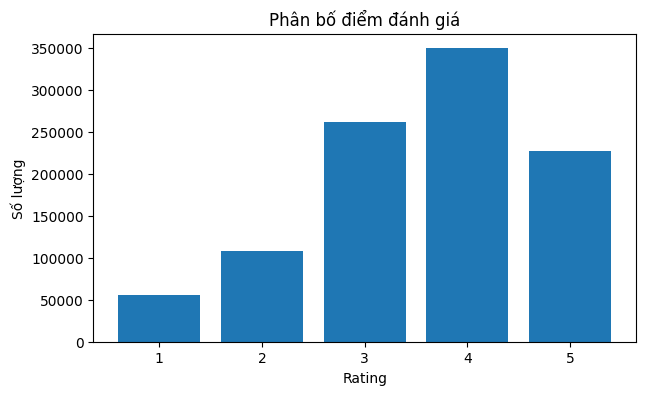

In [ ]:
# 7. EDA: Phân bố rating
rating_counts = ratings['Rating'].value_counts().sort_index()
print(rating_counts)

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title('Phân bố điểm đánh giá')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.show()


## 8. EDA: Các phim được đánh giá nhiều nhất

### Mục đích

Xác định những phim có mức độ phổ biến cao dựa trên số lượt đánh giá.

### Code thực hiện

- Nhóm dữ liệu theo `MovieID` và `Title`.
- Tính `rating_count` và `rating_mean`.
- Sắp xếp giảm dần theo số lượt đánh giá.
- Hiển thị và vẽ biểu đồ Top 10 phim.

### Ý nghĩa

Số lượt đánh giá là tín hiệu quan trọng cho mô hình Popularity-based và giúp phát hiện độ lệch phổ biến trong dữ liệu.


,MovieID,Title,rating_count,rating_mean
2651,2858,American Beauty (1999),3428,4.317386
253,260,Star Wars: Episode IV - A New Hope (1977),2991,4.453694
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990,4.292977
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883,4.022893
466,480,Jurassic Park (1993),2672,3.763847
1848,2028,Saving Private Ryan (1998),2653,4.337354
575,589,Terminator 2: Judgment Day (1991),2649,4.058513
2374,2571,"Matrix, The (1999)",2590,4.315830
1178,1270,Back to the Future (1985),2583,3.990321
579,593,"Silence of the Lambs, The (1991)",2578,4.351823


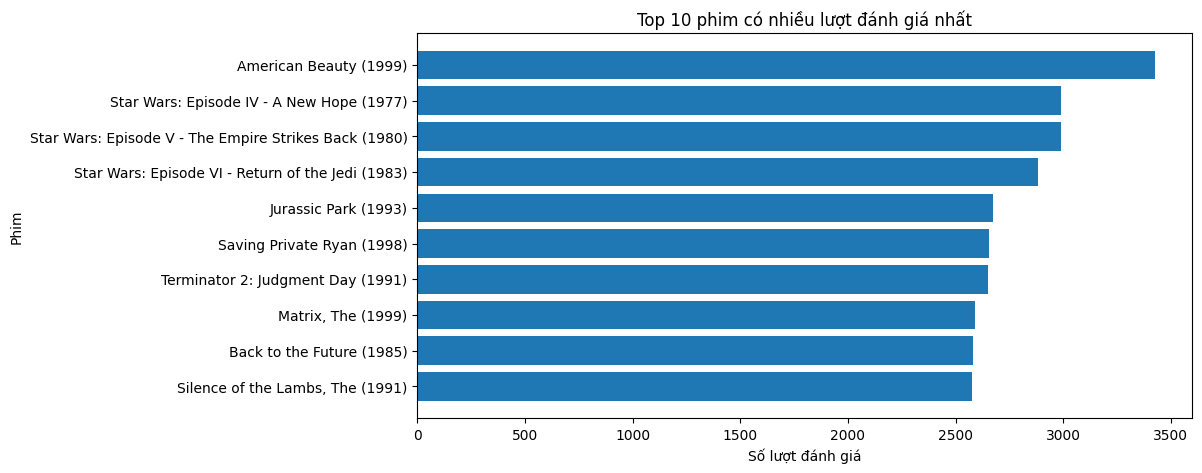

In [ ]:
# 8. EDA: Top phim được đánh giá nhiều nhất
movie_stats = ratings_movies.groupby(['MovieID', 'Title']).agg(
    rating_count=('Rating', 'count'),
    rating_mean=('Rating', 'mean')
).reset_index()

top_count = movie_stats.sort_values('rating_count', ascending=False).head(10)
display(top_count)

plt.figure(figsize=(10, 5))
plt.barh(top_count['Title'][::-1], top_count['rating_count'][::-1])
plt.title('Top 10 phim có nhiều lượt đánh giá nhất')
plt.xlabel('Số lượt đánh giá')
plt.ylabel('Phim')
plt.show()


## 9. EDA: Các phim có rating trung bình cao nhất

### Mục đích

Tìm các phim được đánh giá cao nhưng tránh trường hợp một phim chỉ có vài lượt đánh giá mà vẫn đứng đầu bảng.

### Cách xử lý

Chỉ giữ các phim có ít nhất `50` lượt đánh giá, sau đó mới sắp xếp theo `rating_mean`.

### Ý nghĩa

Điều kiện tối thiểu về số lượt rating làm kết quả đáng tin cậy hơn. Nếu không lọc, một phim có đúng một lượt chấm 5 sao cũng có thể ngang nhiên lên ngôi vô địch.


,MovieID,Title,rating_count,rating_mean
2698,2905,Sanjuro (1962),69,4.608696
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,628,4.560510
309,318,"Shawshank Redemption, The (1994)",2227,4.554558
802,858,"Godfather, The (1972)",2223,4.524966
708,745,"Close Shave, A (1995)",657,4.520548
49,50,"Usual Suspects, The (1995)",1783,4.517106
513,527,Schindler's List (1993),2304,4.510417
1066,1148,"Wrong Trousers, The (1993)",882,4.507937
861,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),470,4.491489
1108,1198,Raiders of the Lost Ark (1981),2514,4.477725


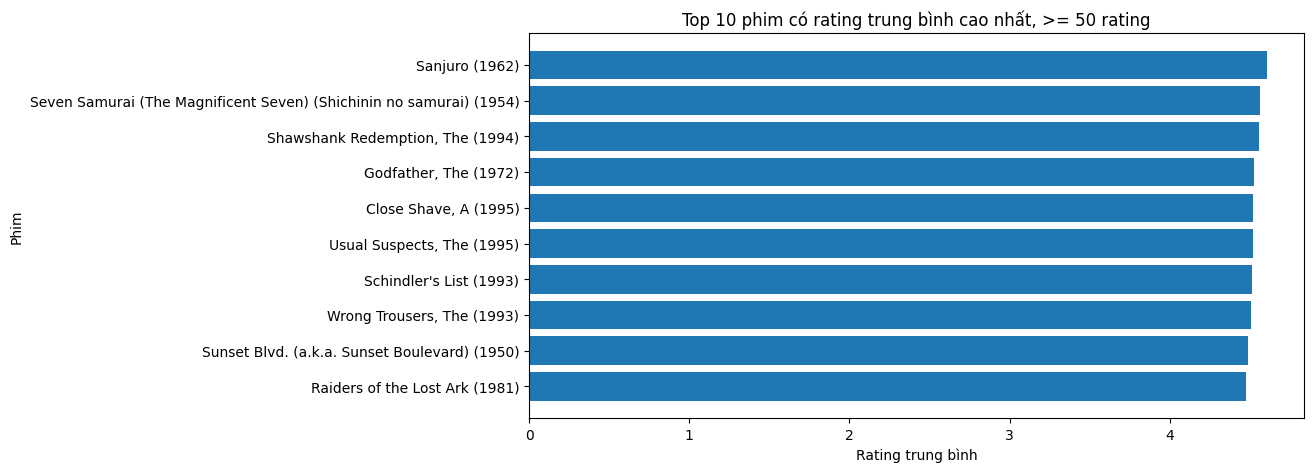

In [ ]:
# 9. EDA: Top phim rating trung bình cao nhất, lọc phim có ít nhất 50 rating
min_ratings = 50
top_mean = movie_stats[movie_stats['rating_count'] >= min_ratings].sort_values('rating_mean', ascending=False).head(10)
display(top_mean)

plt.figure(figsize=(10, 5))
plt.barh(top_mean['Title'][::-1], top_mean['rating_mean'][::-1])
plt.title(f'Top 10 phim có rating trung bình cao nhất, >= {min_ratings} rating')
plt.xlabel('Rating trung bình')
plt.ylabel('Phim')
plt.show()


## 10. EDA: Phân bố thể loại phim

### Mục đích

Xác định số lượng phim thuộc từng thể loại và xem metadata có bị mất cân bằng hay không.

### Code thực hiện

- Cộng tổng từng cột one-hot thể loại.
- Sắp xếp số lượng phim giảm dần.
- Vẽ biểu đồ thanh ngang theo từng genre.

### Ý nghĩa

Phân bố thể loại ảnh hưởng trực tiếp đến Content-based Filtering. Thể loại quá phổ biến có thể xuất hiện nhiều trong danh sách gợi ý hơn các thể loại hiếm.


,Genre,Count
0,Drama,1603
1,Comedy,1200
2,Action,503
3,Thriller,492
4,Romance,471
5,Horror,343
6,Adventure,283
7,Sci-Fi,276
8,Children's,251
9,Crime,211


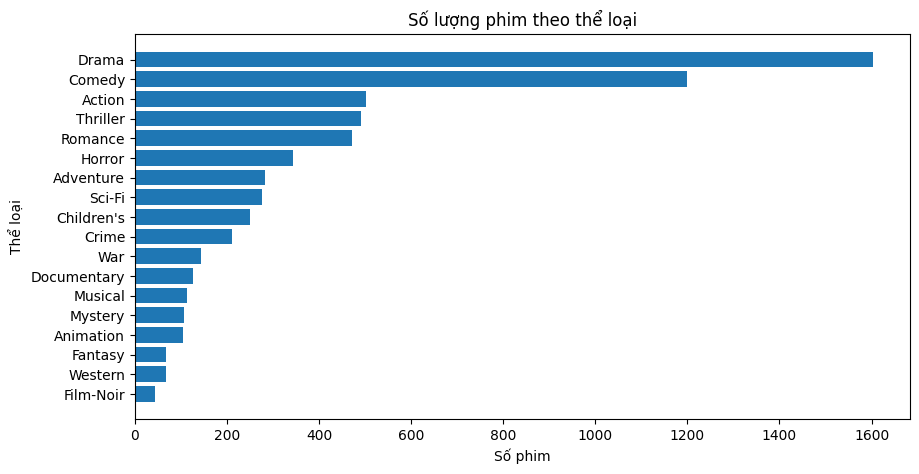

In [ ]:
# 10. EDA: Phân bố thể loại phim
genre_counts = movie_genres.sum().sort_values(ascending=False)
display(genre_counts.reset_index().rename(columns={'index': 'Genre', 0: 'Count'}))

plt.figure(figsize=(10, 5))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])
plt.title('Số lượng phim theo thể loại')
plt.xlabel('Số phim')
plt.ylabel('Thể loại')
plt.show()


## 11. EDA: Mức độ hoạt động của user và movie

### Mục đích

Khảo sát mức độ thưa của dữ liệu thông qua số rating trên mỗi người dùng và mỗi bộ phim.

### Code thực hiện

- Đếm số rating của từng `UserID`.
- Đếm số rating của từng `MovieID`.
- Hiển thị thống kê mô tả.
- Vẽ hai histogram tương ứng.

### Ý nghĩa

Nếu nhiều user hoặc movie có rất ít rating, bài toán cold-start và sparsity sẽ nghiêm trọng hơn. Đây là lý do hệ thống cần baseline và Popularity-based để fallback.


Rating/user mô tả:


,0
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
25%,44.000000
50%,96.000000
75%,208.000000
max,2314.000000


Rating/movie mô tả:


,0
count,3706.000000
mean,269.889099
std,384.047838
min,1.000000
25%,33.000000
50%,123.500000
75%,350.000000
max,3428.000000


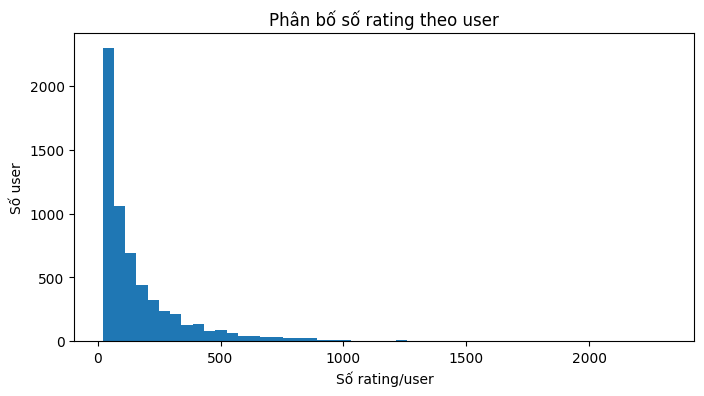

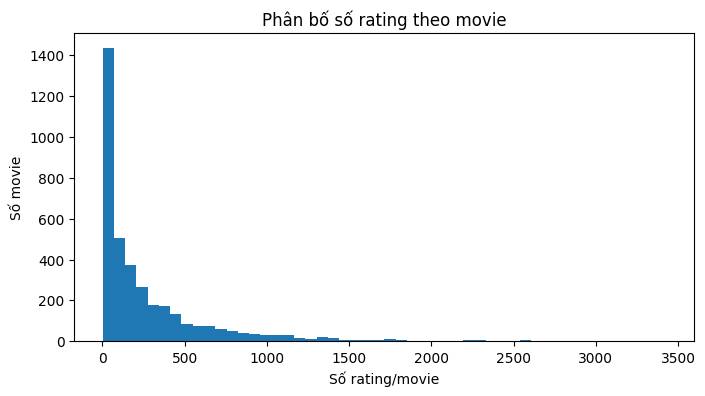

In [ ]:
# 11. EDA: số rating theo user và theo movie
ratings_per_user = ratings.groupby('UserID').size()
ratings_per_movie = ratings.groupby('MovieID').size()

print('Rating/user mô tả:')
display(ratings_per_user.describe())
print('Rating/movie mô tả:')
display(ratings_per_movie.describe())

plt.figure(figsize=(8, 4))
plt.hist(ratings_per_user, bins=50)
plt.title('Phân bố số rating theo user')
plt.xlabel('Số rating/user')
plt.ylabel('Số user')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(ratings_per_movie, bins=50)
plt.title('Phân bố số rating theo movie')
plt.xlabel('Số rating/movie')
plt.ylabel('Số movie')
plt.show()


## 12. Chia tập train, validation và test theo thời gian

### Mục đích

Mô phỏng đúng tình huống thực tế: hệ thống dùng các tương tác trong quá khứ để dự đoán tương tác xảy ra sau đó.

### Phương pháp temporal leave-one-out

Với mỗi người dùng:

- Rating mới nhất được đưa vào tập `test`.
- Rating ngay trước đó được đưa vào tập `validation`.
- Các rating còn lại được dùng làm `train`.

### Vì sao không chia ngẫu nhiên?

Chia ngẫu nhiên có thể làm thông tin tương lai xuất hiện trong tập huấn luyện, gây rò rỉ dữ liệu và khiến kết quả đánh giá đẹp một cách đáng ngờ.

### Kết quả mong đợi

Tạo ba DataFrame `train_df`, `val_df`, `test_df` với kích thước được in ra để kiểm tra.


### Vai trò của các cột

- `Timestamp` quyết định bản ghi nào thuộc train, validation và test.
- Sau khi chia xong, `Timestamp` không được dùng làm đặc trưng dự đoán.
- Các cột còn lại của mỗi tập là `UserID`, `MovieID`, `Rating`; trong đó `Rating` là giá trị thật để học hoặc đánh giá.


In [ ]:
# 12. Chia train/validation/test theo thời gian dạng leave-one-out
# Với recommender system, chia ngẫu nhiên có thể làm sai ngữ cảnh thời gian.
# Ở đây: rating cuối cùng của mỗi user -> test, rating ngay trước đó -> validation, phần còn lại -> train.

ratings_sorted = ratings.sort_values(['UserID', 'Timestamp']).copy()

test_idx = ratings_sorted.groupby('UserID').tail(1).index
remaining_df = ratings_sorted.drop(index=test_idx)

val_idx = remaining_df.groupby('UserID').tail(1).index
train_df = remaining_df.drop(index=val_idx).copy()
val_df = remaining_df.loc[val_idx].copy()
test_df = ratings_sorted.loc[test_idx].copy()

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)
print('Số user trong train:', train_df['UserID'].nunique())
print('Số user trong validation:', val_df['UserID'].nunique())
print('Số user trong test:', test_df['UserID'].nunique())


Train: (988129, 4)
Validation: (6040, 4)
Test: (6040, 4)
Số user trong train: 6040
Số user trong validation: 6040
Số user trong test: 6040


## 13. Ánh xạ UserID và MovieID thành chỉ số liên tục

### Mục đích

Ma trận NumPy và ma trận thưa cần chỉ số hàng, cột liên tục từ 0. Trong khi đó, `UserID` và `MovieID` gốc không nhất thiết liên tục.

### Các mapping được tạo

- `user_to_idx`: UserID → chỉ số hàng.
- `idx_to_user`: chỉ số hàng → UserID.
- `movie_to_idx`: MovieID → chỉ số cột.
- `idx_to_movie`: chỉ số cột → MovieID.

### Kết quả mong đợi

Có số lượng người dùng `n_users`, số lượng phim `n_movies` và các từ điển mapping dùng cho SVD.


### Lưu ý về ý nghĩa của ID

`UserID` và `MovieID` là biến phân loại định danh. Giá trị ID lớn hơn không có nghĩa người dùng hoặc phim “lớn hơn”. Việc ánh xạ chỉ giúp mô hình sử dụng index liên tục; Embedding và SVD sẽ tự học biểu diễn ẩn tương ứng.


In [ ]:
# 13. Tạo các mapping UserID/MovieID về index liên tục
unique_users = ratings['UserID'].unique()
unique_movies = ratings['MovieID'].unique()

user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

movie_to_idx = {movie: idx for idx, movie in enumerate(unique_movies)}
idx_to_movie = {idx: movie for movie, idx in movie_to_idx.items()}

n_users = len(unique_users)
n_movies = len(unique_movies)

print('n_users:', n_users)
print('n_movies:', n_movies)


n_users: 6040
n_movies: 3706


## 14. Xây dựng hàm dự đoán cơ sở và xử lý cold-start

### Mục đích

Tạo một giá trị dự đoán đơn giản để:

- Làm baseline cho bài toán dự đoán rating.
- Xử lý user hoặc movie chưa xuất hiện trong dữ liệu train.
- Tránh mô hình SVD bị lỗi khi gặp ID lạ.

### Công thức dự đoán

Điểm dự đoán kết hợp:

- 50% rating trung bình của phim.
- 30% rating trung bình của người dùng.
- 20% rating trung bình toàn cục.

Kết quả được giới hạn trong khoảng từ 1 đến 5 bằng `np.clip`.

### Đánh giá

Cell tính MAE và RMSE của baseline trên tập test. Phần này hỗ trợ hệ thống nhưng không được tính là một mô hình gợi ý độc lập thứ năm.


### Đầu vào và đặc trưng

- Khi xây dựng: dùng `UserID`, `MovieID`, `Rating` trong `train_df` để tính `user_mean`, `movie_mean`, `GLOBAL_MEAN`.
- Khi dự đoán: hàm chỉ nhận `user_id` và `movie_id`; không cần biết `Rating` thật.
- Ba giá trị trung bình là **đặc trưng thống kê dẫn xuất**, không phải ba cột gốc mới.


In [ ]:
# 14. Mean Baseline cho bài toán dự đoán rating
# Mô hình này dự đoán rating dựa trên:
# - Trung bình rating của phim
# - Trung bình rating của người dùng
# - Trung bình rating toàn bộ dữ liệu
# Đầu vào suy luận: user_id, movie_id. Rating chỉ dùng để tính thống kê từ train.

GLOBAL_MEAN = train_df['Rating'].mean()

user_mean = (
    train_df.groupby('UserID')['Rating']
    .mean()
    .to_dict()
)

movie_mean = (
    train_df.groupby('MovieID')['Rating']
    .mean()
    .to_dict()
)

def rmse(y_true, y_pred):
    return float(
        np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
    )

def predict_mean_baseline(user_id, movie_id):
    user_rating_mean = user_mean.get(
        user_id,
        GLOBAL_MEAN
    )
    movie_rating_mean = movie_mean.get(
        movie_id,
        GLOBAL_MEAN
    )
    predicted_rating = (
        0.5 * movie_rating_mean
        + 0.3 * user_rating_mean
        + 0.2 * GLOBAL_MEAN
    )
    return float(
        np.clip(
            predicted_rating,
            1.0,
            5.0
        )
    )

def predict_baseline(user_id, movie_id):
    """
    Giá trị dự phòng khi SVD hoặc Neural Network
    gặp user/movie chưa có trong tập train.
    """
    return predict_mean_baseline(
        user_id,
        movie_id
    )

# Dự đoán trên toàn bộ tập test
test_pred_baseline = [
    predict_mean_baseline(user_id, movie_id)
    for user_id, movie_id in zip(
        test_df['UserID'],
        test_df['MovieID']
    )
]


# Tính MAE và RMSE
mae_baseline = mean_absolute_error(
    test_df['Rating'],
    test_pred_baseline
)

rmse_baseline = rmse(
    test_df['Rating'],
    test_pred_baseline
)

print(
    'Mean Baseline MAE:',
    round(mae_baseline, 4)
)

print(
    'Mean Baseline RMSE:',
    round(rmse_baseline, 4)
)

Mean Baseline MAE: 0.8309
Mean Baseline RMSE: 1.0218


## 15. Mô hình Popularity-based Recommendation

### Nguyên lý

Mô hình gợi ý các phim phổ biến dựa trên cả số lượt đánh giá và điểm trung bình. Đây là baseline Top-N không cá nhân hoá, đặc biệt hữu ích cho người dùng mới.

### Vì sao dùng weighted score?

Nếu chỉ sắp xếp theo rating trung bình, phim có rất ít lượt đánh giá có thể đứng quá cao. Công thức weighted score kéo điểm của phim ít rating về gần điểm trung bình toàn cục `C`.

Trong đó:

- `rating_count`: số lượt đánh giá của phim.
- `rating_mean`: rating trung bình của phim.
- `C`: rating trung bình toàn bộ tập train.
- `m`: ngưỡng số rating tại phân vị 75%.

### Kết quả mong đợi

Hàm `recommend_popular(top_n)` trả về danh sách phim có `popularity_score` cao nhất.


### Đầu vào và đầu ra

- Cột dùng để xây dựng: `MovieID`, `Rating` trong `train_df`.
- Các đặc trưng dẫn xuất: `rating_count`, `rating_mean`, `popularity_score`.
- `UserID` không tham gia xếp hạng nên mô hình này không cá nhân hóa.
- `Title`, `Genres` chỉ được merge sau khi tính điểm để hiển thị.


In [ ]:
# 15. Mô hình Popularity-based Recommendation
# Sử dụng MovieID và Rating để tạo rating_count, rating_mean và popularity_score.
# Title/Genres chỉ được nối sau đó để hiển thị, không tham gia tính điểm.

movie_pop = train_df.groupby('MovieID').agg(
    rating_count=('Rating', 'count'),
    rating_mean=('Rating', 'mean')
).reset_index()

C = train_df['Rating'].mean()
m = movie_pop['rating_count'].quantile(0.75)

movie_pop['popularity_score'] = (
    (movie_pop['rating_count'] / (movie_pop['rating_count'] + m)) * movie_pop['rating_mean'] +
    (m / (movie_pop['rating_count'] + m)) * C
)

movie_pop = movie_pop.merge(movies_clean[['MovieID', 'Title', 'Genres']], on='MovieID', how='left')

def recommend_popular(top_n=10):
    return movie_pop.sort_values('popularity_score', ascending=False).head(top_n)[
        ['MovieID', 'Title', 'Genres', 'rating_count', 'rating_mean', 'popularity_score']
    ]

display(recommend_popular(10))


,MovieID,Title,Genres,rating_count,rating_mean,popularity_score
309,318,"Shawshank Redemption, The (1994)",Drama,2198,4.553230,4.420732
802,858,"Godfather, The (1972)",Action|Crime|Drama,2204,4.524047,4.395830
513,527,Schindler's List (1993),Drama|War,2277,4.509442,4.386724
1108,1198,Raiders of the Lost Ark (1981),Action|Adventure,2498,4.476381,4.367228
49,50,"Usual Suspects, The (1995)",Crime|Thriller,1764,4.519841,4.365591
253,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,2974,4.452925,4.361868
2556,2762,"Sixth Sense, The (1999)",Thriller,2404,4.408486,4.304167
713,750,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,1358,4.446981,4.270829
851,912,Casablanca (1942),Drama|Romance|War,1655,4.412689,4.268613
579,593,"Silence of the Lambs, The (1991)",Drama|Thriller,2562,4.351288,4.259458


## 16. Mô hình Content-based Filtering

### Nguyên lý

Content-based gợi ý phim dựa trên sự tương đồng giữa đặc trưng nội dung của phim và hồ sơ sở thích của người dùng.

### Quy trình

1. Dùng các cột one-hot thể loại làm vector đặc trưng phim.
2. Chuẩn hóa vector bằng L2 norm.
3. Lấy các phim người dùng đánh giá từ 4 điểm trở lên.
4. Tính trung bình có trọng số để tạo user profile.
5. Dùng cosine similarity giữa user profile và toàn bộ phim.
6. Loại các phim người dùng đã xem.
7. Trả về Top-N phim có độ tương đồng cao nhất.

### Xử lý thiếu dữ liệu

Nếu người dùng chưa có đủ lịch sử rating tích cực, hệ thống fallback sang Popularity-based.


### Đầu vào và đặc trưng

- Đặc trưng phim: 18 cột one-hot thể loại được tạo từ `Genres`.
- Tín hiệu sở thích user: các dòng `UserID`, `MovieID`, `Rating >= 4` trong `train_df`.
- `Rating` được dùng làm trọng số khi lấy trung bình vector phim, không phải là một chiều trong vector genre.
- Khi gọi hàm: đầu vào là `user_id` và `top_n`.
- `Title`, `Year`, `CleanTitle`, `Gender`, `Age`, `Occupation`, `ZipCode` không tham gia tính cosine trong phiên bản hiện tại.


In [ ]:
# 16. Mô hình Content-based Filtering
# Feature phim: các cột one-hot genre.
# Profile user: trung bình có trọng số Rating của các phim user chấm từ 4 trở lên.

genre_cols = list(movie_genres.columns)
movie_feature_df = movies_clean[['MovieID'] + genre_cols].copy()
movie_feature_df = movie_feature_df.set_index('MovieID')

# Chuẩn hoá vector genre theo L2 norm để phim có nhiều thể loại không bị lợi thế quá mức.
raw_movie_feature_matrix = movie_feature_df.values.astype(float)
row_norms = np.linalg.norm(raw_movie_feature_matrix, axis=1, keepdims=True)
movie_feature_matrix = raw_movie_feature_matrix / np.where(row_norms == 0, 1, row_norms)

# Map MovieID -> vị trí trong movie_feature_matrix
movie_feature_id_to_pos = {movie_id: pos for pos, movie_id in enumerate(movie_feature_df.index)}

def build_user_profile(user_id, min_rating=4):
    user_ratings = train_df[(train_df['UserID'] == user_id) & (train_df['Rating'] >= min_rating)]
    if user_ratings.empty:
        return None
    vectors = []
    weights = []
    for _, row in user_ratings.iterrows():
        mid = row['MovieID']
        if mid in movie_feature_id_to_pos:
            vectors.append(movie_feature_matrix[movie_feature_id_to_pos[mid]])
            weights.append(row['Rating'])
    if not vectors:
        return None
    vectors = np.array(vectors)
    weights = np.array(weights)
    profile = np.average(vectors, axis=0, weights=weights)
    profile_norm = np.linalg.norm(profile)
    if profile_norm > 0:
        profile = profile / profile_norm
    return profile

def recommend_content_based(user_id, top_n=10):
    profile = build_user_profile(user_id)
    if profile is None or np.linalg.norm(profile) == 0:
        return recommend_popular(top_n)

    scores = cosine_similarity(profile.reshape(1, -1), movie_feature_matrix)[0]
    scored = pd.DataFrame({
        'MovieID': movie_feature_df.index,
        'content_score': scores
    })

    watched = set(train_df[train_df['UserID'] == user_id]['MovieID'])
    scored = scored[~scored['MovieID'].isin(watched)]
    scored = scored.merge(movies_clean[['MovieID', 'Title', 'Genres']], on='MovieID', how='left')
    return scored.sort_values('content_score', ascending=False).head(top_n)

# Demo content-based
sample_user = int(train_df['UserID'].iloc[0])
print('Sample user:', sample_user)
display(recommend_content_based(sample_user, 10))


Sample user: 1


,MovieID,content_score,Title,Genres
985,1014,0.828191,Pollyanna (1960),Children's|Comedy|Drama
32,34,0.828191,Babe (1995),Children's|Comedy|Drama
1718,1812,0.828191,Wide Awake (1998),Children's|Comedy|Drama
891,917,0.794934,"Little Princess, The (1939)",Children's|Drama
996,1026,0.794934,So Dear to My Heart (1949),Children's|Drama
983,1012,0.794934,Old Yeller (1957),Children's|Drama
984,1013,0.794934,"Parent Trap, The (1961)",Children's|Drama
1975,2079,0.794934,Kidnapped (1960),Children's|Drama
1480,1547,0.794934,Shiloh (1997),Children's|Drama
2291,2400,0.794934,Prancer (1989),Children's|Drama


## 17. Matrix Factorization bằng SVD

### Nguyên lý

SVD phân rã ma trận user–movie thành các nhân tố ẩn đại diện cho sở thích người dùng và đặc điểm tiềm ẩn của phim.

### User-mean centering

Trước khi phân rã, rating của mỗi người dùng được trừ đi rating trung bình của chính người đó. Mô hình chỉ học phần sai lệch còn lại, thay vì hiểu các ô chưa rating là điểm 0.

### Các bước chính

1. Chuyển rating train thành ma trận thưa.
2. Thử các giá trị số nhân tố ẩn `K = 20, 50, 100`.
3. Chạy SVD một lần với `max_k`.
4. Cắt các ma trận để đánh giá từng K.
5. Chọn `BEST_K` có RMSE thấp nhất trên validation.
6. Tạo ma trận dự đoán `pred_matrix`.

### Kết quả mong đợi

Cell in bảng MAE/RMSE theo từng K và chọn giá trị K tốt nhất.


### Đầu vào và đặc trưng

- Dữ liệu quan sát: `UserID`, `MovieID`, `Rating` trong `train_df`.
- `UserID` xác định hàng, `MovieID` xác định cột, `Rating` là giá trị của ô đã quan sát.
- `Timestamp`, `Genres` và thuộc tính nhân khẩu học không được đưa vào SVD.
- Sau phân rã, `U`, `sigma`, `Vt` là các đặc trưng ẩn do mô hình học được.


In [ ]:
# 17. Matrix Factorization bằng SVD có user-mean centering và thử nhiều K
# Ý tưởng: chỉ phân rã phần residual = rating - mean_user trên các rating đã quan sát.
# Như vậy ô chưa rating không bị hiểu nhầm là rating 0.
# Cột sử dụng: UserID -> hàng, MovieID -> cột, Rating -> giá trị quan sát.

train_rows = train_df['UserID'].map(user_to_idx).values
train_cols = train_df['MovieID'].map(movie_to_idx).values
train_vals = train_df['Rating'].values.astype(float)

user_mean_series = train_df.groupby('UserID')['Rating'].mean()
user_mean_vector = np.array([user_mean_series.get(uid, GLOBAL_MEAN) for uid in unique_users])
centered_vals = train_vals - train_df['UserID'].map(user_mean_series).values

train_matrix_centered = csr_matrix((centered_vals, (train_rows, train_cols)), shape=(n_users, n_movies))

candidate_k = [20, 50, 100]
candidate_k = [k for k in candidate_k if k < min(n_users, n_movies)]
max_k = max(candidate_k)

# Chỉ chạy SVD một lần với max_k, sau đó cắt lại để đánh giá các K nhỏ hơn.
# Cách này nhanh hơn nhiều so với chạy svds riêng cho từng K.
U_full, singular_values_full, Vt_full = svds(train_matrix_centered, k=max_k)
order = np.argsort(singular_values_full)[::-1]
U_full = U_full[:, order]
singular_values_full = singular_values_full[order]
Vt_full = Vt_full[order, :]

def build_svd_prediction_matrix(k):
    U_k = U_full[:, :k]
    sigma_k = singular_values_full[:k]
    Vt_k = Vt_full[:k, :]
    residual_pred = (U_k * sigma_k) @ Vt_k
    pred = residual_pred + user_mean_vector.reshape(-1, 1)
    return np.clip(pred, 1, 5)

def evaluate_svd_k(k, eval_df):
    pred = build_svd_prediction_matrix(k)
    y_pred = []
    for u, m in zip(eval_df['UserID'], eval_df['MovieID']):
        if u in user_to_idx and m in movie_to_idx:
            y_pred.append(pred[user_to_idx[u], movie_to_idx[m]])
        else:
            y_pred.append(predict_baseline(u, m))
    return {
        'K': k,
        'MAE_val': mean_absolute_error(eval_df['Rating'], y_pred),
        'RMSE_val': rmse(eval_df['Rating'], y_pred)
    }

svd_k_results = pd.DataFrame([evaluate_svd_k(k, val_df) for k in candidate_k])
display(svd_k_results)

BEST_K = int(svd_k_results.sort_values('RMSE_val').iloc[0]['K'])
print('K được chọn theo validation RMSE:', BEST_K)

pred_matrix = build_svd_prediction_matrix(BEST_K)
print('Pred matrix shape:', pred_matrix.shape)


,K,MAE_val,RMSE_val
0,20,0.822315,1.041269
1,50,0.821192,1.039393
2,100,0.823794,1.042221


K được chọn theo validation RMSE: 50
Pred matrix shape: (6040, 3706)


## 18. Dự đoán rating bằng SVD

### Mục đích

Tạo hàm nhận `user_id` và `movie_id`, sau đó trả về rating dự đoán theo ma trận SVD.

### Xử lý trường hợp đặc biệt

Nếu user hoặc movie không có trong mapping, hàm sử dụng baseline thay vì báo lỗi.

### Đánh giá

Dự đoán toàn bộ tập test rồi tính:

- `MAE`: sai số tuyệt đối trung bình.
- `RMSE`: căn bậc hai của sai số bình phương trung bình.

Giá trị càng thấp cho thấy dự đoán rating càng gần dữ liệu thật.


### Đầu vào khi suy luận

Hàm chỉ nhận `user_id` và `movie_id`. Mô hình tra latent factor tương ứng và cộng lại user mean để tạo rating dự đoán. `Rating` thật chỉ dùng sau đó để tính MAE/RMSE, không phải đầu vào của hàm dự đoán.


In [ ]:
# 18. Hàm dự đoán rating bằng SVD
# SVD đã được center theo user mean để giảm sai lệch do ma trận sparse.

def predict_svd(user_id, movie_id):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return predict_baseline(user_id, movie_id)
    pred = pred_matrix[user_to_idx[user_id], movie_to_idx[movie_id]]
    return float(np.clip(pred, 1, 5))

# Đánh giá SVD trên test.
test_pred_svd = [predict_svd(u, m) for u, m in zip(test_df['UserID'], test_df['MovieID'])]
mae_svd = mean_absolute_error(test_df['Rating'], test_pred_svd)
rmse_svd = rmse(test_df['Rating'], test_pred_svd)

print('SVD MAE:', mae_svd)
print('SVD RMSE:', rmse_svd)


SVD MAE: 0.8481425171103499
SVD RMSE: 1.0668076969362623


## 19. Sinh danh sách Top-N bằng SVD

### Mục đích

Chuyển mô hình dự đoán rating thành chức năng gợi ý phim thực tế.

### Quy trình

1. Lấy toàn bộ điểm dự đoán của người dùng.
2. Tạo tập phim người dùng đã xem trong train.
3. Loại các phim đã xem khỏi danh sách ứng viên.
4. Gắn lại tên phim và thể loại.
5. Sắp xếp theo `svd_score` giảm dần.
6. Trả về Top-N phim.

Nếu người dùng chưa có trong dữ liệu, hàm trả về danh sách Popularity-based.


### Đầu vào và metadata

- Đầu vào trực tiếp: `user_id`, `top_n`.
- Mỗi `MovieID` ứng viên được chấm bằng `svd_score`.
- `Title` và `Genres` chỉ được gắn lại sau khi xếp hạng để hiển thị.


In [ ]:
# 19. Gợi ý phim bằng SVD

def recommend_svd(user_id, top_n=10):
    if user_id not in user_to_idx:
        return recommend_popular(top_n)

    user_index = user_to_idx[user_id]
    user_scores = pred_matrix[user_index].copy()

    watched = set(train_df[train_df['UserID'] == user_id]['MovieID'])
    candidate_movie_ids = []
    candidate_scores = []

    for movie_id, movie_index in movie_to_idx.items():
        if movie_id not in watched:
            candidate_movie_ids.append(movie_id)
            candidate_scores.append(user_scores[movie_index])

    recs = pd.DataFrame({
        'MovieID': candidate_movie_ids,
        'svd_score': candidate_scores
    })
    recs['svd_score'] = recs['svd_score'].clip(1, 5)
    recs = recs.merge(movies_clean[['MovieID', 'Title', 'Genres']], on='MovieID', how='left')
    return recs.sort_values('svd_score', ascending=False).head(top_n)

display(recommend_svd(sample_user, 10))


,MovieID,svd_score,Title,Genres
120,356,4.437211,Forrest Gump (1994),Comedy|Romance|War
41,110,4.367256,Braveheart (1995),Action|Drama|War
339,364,4.320595,"Lion King, The (1994)",Animation|Children's|Musical
62,480,4.319519,Jurassic Park (1993),Action|Adventure|Sci-Fi
185,1250,4.295337,"Bridge on the River Kwai, The (1957)",Drama|War
156,2081,4.292903,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance
72,590,4.289319,Dances with Wolves (1990),Adventure|Drama|Western
355,3753,4.288608,"Patriot, The (2000)",Action|Drama|War
162,1387,4.284691,Jaws (1975),Action|Horror
1488,1272,4.282897,Patton (1970),Drama|War


## 20. Neural Network: Neural Collaborative Filtering

### Mục tiêu

Mô hình Neural Network học mối quan hệ phi tuyến giữa người dùng và phim. Thay vì chỉ phân rã ma trận theo phép nhân tuyến tính như SVD, mô hình sử dụng **Embedding** kết hợp với các lớp **Dense** để học các mẫu sở thích phức tạp hơn.

### Đầu vào, nhãn và đặc trưng học được

Mỗi mẫu huấn luyện được tách thành:

- **Đầu vào X1:** `UserID` được ánh xạ thành `user_index` kiểu số nguyên.
- **Đầu vào X2:** `MovieID` được ánh xạ thành `movie_index` kiểu số nguyên.
- **Nhãn y:** `Rating` thật từ 1 đến 5, được chuẩn hóa thành `rating_scaled` trong khoảng 0–1.

Công thức chuẩn hóa nhãn:

`rating_scaled = (rating - 1) / 4`

Khi dự đoán, kết quả được đổi ngược về thang 1–5:

`rating_pred = 1 + 4 × rating_scaled_pred`

> `Rating` là **nhãn mục tiêu**, không phải tensor đầu vào của mạng. Hai tensor đi vào `nn_model` chỉ là `user_index` và `movie_index`.

### Những cột không được dùng trong mạng hiện tại

`Gender`, `Age`, `Occupation`, `ZipCode`, `Timestamp`, `Title`, `Year`, `CleanTitle` và vector genre không được truyền vào Neural CF. Sở thích được biểu diễn bằng user/movie embedding học từ lịch sử rating.

### Kiến trúc mạng

| Thành phần | Kích thước / chức năng |
|---|---|
| User Input | Một `user_index` cho mỗi mẫu |
| Movie Input | Một `movie_index` cho mỗi mẫu |
| User Embedding | Mỗi người dùng được biểu diễn bởi vector 32 chiều |
| Movie Embedding | Mỗi phim được biểu diễn bởi vector 32 chiều |
| Concatenate | Ghép hai vector thành vector 64 chiều |
| Dense 128 + ReLU | Học tương tác phi tuyến |
| Dropout 0.20 | Giảm overfitting |
| Dense 64 + ReLU | Rút trích đặc trưng sâu hơn |
| Dropout 0.10 | Tiếp tục regularization |
| Dense 1 + Sigmoid | Dự đoán rating chuẩn hóa 0–1 |

### Cách huấn luyện

- Hàm mất mát: `Mean Squared Error` giữa nhãn `rating_scaled` thật và dự đoán.
- Bộ tối ưu: `Adam`.
- Batch size: `4096`.
- Tối đa: `15 epochs`.
- `EarlyStopping`: dừng nếu validation loss không cải thiện sau 3 epochs.
- `ReduceLROnPlateau`: giảm learning rate khi mô hình học chững lại.

### Mô hình tạo ra những gì?

Sau khi chạy cell, notebook nhận được:

1. `nn_model`: mô hình Neural Collaborative Filtering đã huấn luyện.
2. `nn_history_df`: lịch sử loss, MAE, RMSE theo từng epoch.
3. `mae_nn`: sai số tuyệt đối trung bình trên tập test.
4. `rmse_nn`: căn bậc hai sai số bình phương trung bình trên tập test.
5. `predict_neural_rating(user_id, movie_id)`: dự đoán rating 1–5.
6. `recommend_neural_network(user_id, top_n)`: danh sách Top-N phim cá nhân hóa.
7. Biểu đồ train/validation loss để nhận biết overfitting.

### Cách đọc kết quả

- `MAE`, `RMSE`, `loss`, `val_loss`: **càng thấp càng tốt**.
- Nếu `loss` giảm nhưng `val_loss` tăng, mô hình đang **overfitting**.
- Số epoch cao không tự động nghĩa là mô hình tốt; epoch tốt nhất là epoch có `val_loss` thấp nhất.


Model: "neural_collaborative_filtering"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    193,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 32)     │    118,592 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_user        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_movie       │ (None, 32)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_user_movie   │ (None, 64)        │          0 │ flatten_user[0][… │
│ (Concatenate)       │                   │            │ flatten_movie[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │      8,320 │ concat_user_movi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ dense_128[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      8,256 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_64[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_scaled       │ (None, 1)         │         65 │ dropout_10[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 328,513 (1.25 MB)

 Trainable params: 328,513 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0590 - mae_scaled: 0.1930 - rmse_scaled: 0.2423 - val_loss: 0.0557 - val_mae_scaled: 0.1870 - val_rmse_scaled: 0.2352 - learning_rate: 0.0010
Epoch 2/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0510 - mae_scaled: 0.1784 - rmse_scaled: 0.2250 - val_loss: 0.0544 - val_mae_scaled: 0.1842 - val_rmse_scaled: 0.2323 - learning_rate: 0.0010
Epoch 3/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0498 - mae_scaled: 0.1758 - rmse_scaled: 0.2223 - val_loss: 0.0536 - val_mae_scaled: 0.1822 - val_rmse_scaled: 0.2305 - learning_rate: 0.0010
Epoch 4/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0487 - mae_scaled: 0.1736 - rmse_scaled: 0.2195 - val_loss: 0.0531 - val_mae_scaled: 0.1811 - val_rmse_scaled: 0.2294 - learning_rate: 0.0010
Epoch 5/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0476 - mae_scaled: 0.1715 - rmse_scaled: 0.2170 - val_loss: 0.0528 - val_mae_scaled: 0.1804 - val_rmse_scaled: 0.2285 - le

,loss,mae_scaled,rmse_scaled,val_loss,val_mae_scaled,val_rmse_scaled,learning_rate
Epoch,,,,,,,
1,0.059040,0.193003,0.242348,0.055686,0.186998,0.235246,0.001000
2,0.051015,0.178355,0.225039,0.054377,0.184190,0.232336,0.001000
3,0.049827,0.175846,0.222272,0.053578,0.182151,0.230499,0.001000
4,0.048657,0.173569,0.219503,0.053114,0.181090,0.229373,0.001000
5,0.047611,0.171538,0.216984,0.052764,0.180403,0.228495,0.001000
6,0.046851,0.169954,0.215109,0.052764,0.180379,0.228385,0.001000
7,0.045627,0.167452,0.212177,0.052704,0.180135,0.228235,0.000500
8,0.044764,0.165706,0.210124,0.052717,0.179729,0.228264,0.000250
9,0.044207,0.164527,0.208796,0.052718,0.179639,0.228270,0.000125


Epoch tốt nhất theo val_loss: 14
Neural Network MAE trên test: 0.7341 -> CÀNG THẤP CÀNG TỐT
Neural Network RMSE trên test: 0.9377 -> CÀNG THẤP CÀNG TỐT
Dự đoán lệch trung bình khoảng 0.73 điểm trên thang 1-5.


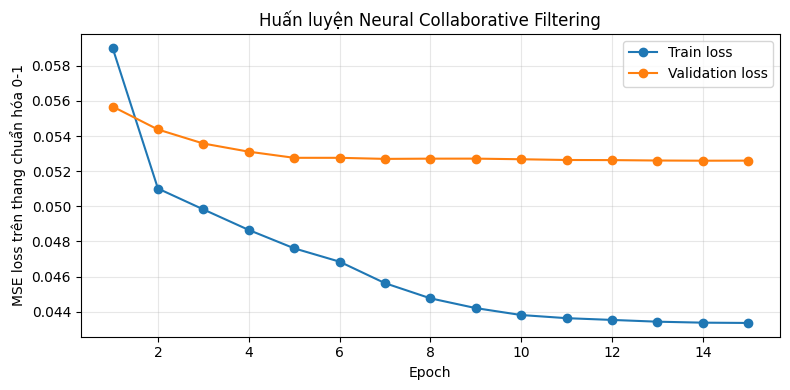

Ví dụ dự đoán rating bằng Neural Network:
UserID = 1, MovieID = 1193: 4.538


,MovieID,nn_score,Title,Genres
0,318,4.763237,"Shawshank Redemption, The (1994)",Drama
1,1198,4.710939,Raiders of the Lost Ark (1981),Action|Adventure
2,2905,4.662695,Sanjuro (1962),Action|Adventure
3,50,4.611957,"Usual Suspects, The (1995)",Crime|Thriller
4,1250,4.611765,"Bridge on the River Kwai, The (1957)",Drama|War
5,1148,4.606110,"Wrong Trousers, The (1993)",Animation|Comedy
6,593,4.601793,"Silence of the Lambs, The (1991)",Drama|Thriller
7,1262,4.595941,"Great Escape, The (1963)",Adventure|War
8,953,4.587449,It's a Wonderful Life (1946),Drama
9,2019,4.575666,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama


In [ ]:
# 20. Neural Network - Neural Collaborative Filtering
# Học embedding cho user/movie và mô hình hóa tương tác phi tuyến bằng Dense.

# Chuẩn bị hai tensor đầu vào X: user_index và movie_index
# Rating không nằm trong X; Rating được chuẩn hóa để làm nhãn y.
train_user_idx_nn = (
    train_df['UserID']
    .map(user_to_idx)
    .astype('int32')
    .values
    .reshape(-1, 1)
)

train_movie_idx_nn = (
    train_df['MovieID']
    .map(movie_to_idx)
    .astype('int32')
    .values
    .reshape(-1, 1)
)

val_user_idx_nn = (
    val_df['UserID']
    .map(user_to_idx)
    .astype('int32')
    .values
    .reshape(-1, 1)
)

val_movie_idx_nn = (
    val_df['MovieID']
    .map(movie_to_idx)
    .astype('int32')
    .values
    .reshape(-1, 1)
)

test_user_idx_nn = (
    test_df['UserID']
    .map(user_to_idx)
    .astype('int32')
    .values
    .reshape(-1, 1)
)

test_movie_idx_nn = (
    test_df['MovieID']
    .map(movie_to_idx)
    .astype('int32')
    .values
    .reshape(-1, 1)
)

# Chuẩn hóa nhãn y là Rating từ thang 1-5 về 0-1
y_train_nn = (
    train_df['Rating'].values.astype('float32') - 1.0
) / 4.0

y_val_nn = (
    val_df['Rating'].values.astype('float32') - 1.0
) / 4.0

# Xây dựng mô hình
EMBEDDING_DIM = 32

user_input = keras.Input(
    shape=(1,),
    dtype='int32',
    name='user_input'
)

movie_input = keras.Input(
    shape=(1,),
    dtype='int32',
    name='movie_input'
)

user_embedding = layers.Embedding(
    input_dim=n_users,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=keras.regularizers.l2(1e-6),
    name='user_embedding'
)(user_input)

movie_embedding = layers.Embedding(
    input_dim=n_movies,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=keras.regularizers.l2(1e-6),
    name='movie_embedding'
)(movie_input)

user_vector = layers.Flatten(
    name='flatten_user'
)(user_embedding)

movie_vector = layers.Flatten(
    name='flatten_movie'
)(movie_embedding)

x = layers.Concatenate(
    name='concat_user_movie'
)([user_vector, movie_vector])

x = layers.Dense(
    128,
    activation='relu',
    name='dense_128'
)(x)

x = layers.Dropout(
    0.20,
    name='dropout_20'
)(x)

x = layers.Dense(
    64,
    activation='relu',
    name='dense_64'
)(x)

x = layers.Dropout(
    0.10,
    name='dropout_10'
)(x)

rating_scaled_output = layers.Dense(
    1,
    activation='sigmoid',
    name='rating_scaled'
)(x)

nn_model = keras.Model(
    inputs=[user_input, movie_input],
    outputs=rating_scaled_output,
    name='neural_collaborative_filtering'
)

nn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae_scaled'
        ),
        keras.metrics.RootMeanSquaredError(
            name='rmse_scaled'
        )
    ]
)

# Callback hạn chế overfitting
callbacks_nn = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1
    )
]

nn_model.summary()

# Huấn luyện mô hình
history_nn = nn_model.fit(
    x=[
        train_user_idx_nn,
        train_movie_idx_nn
    ],
    y=y_train_nn,
    validation_data=(
        [
            val_user_idx_nn,
            val_movie_idx_nn
        ],
        y_val_nn
    ),
    epochs=15,
    batch_size=4096,
    callbacks=callbacks_nn,
    verbose=1
)

# Hiển thị lịch sử huấn luyện
nn_history_df = pd.DataFrame(
    history_nn.history
)

nn_history_df.index = np.arange(
    1,
    len(nn_history_df) + 1
)

nn_history_df.index.name = 'Epoch'

display(nn_history_df)

# Dự đoán trên tập test
test_pred_nn_scaled = nn_model.predict(
    [
        test_user_idx_nn,
        test_movie_idx_nn
    ],
    batch_size=8192,
    verbose=0
).reshape(-1)

test_pred_nn = np.clip(
    1.0 + 4.0 * test_pred_nn_scaled,
    1.0,
    5.0
)

mae_nn = mean_absolute_error(
    test_df['Rating'],
    test_pred_nn
)

rmse_nn = rmse(
    test_df['Rating'],
    test_pred_nn
)

best_epoch_nn = int(
    nn_history_df['val_loss'].idxmin()
)

print(
    f'Epoch tốt nhất theo val_loss: '
    f'{best_epoch_nn}'
)

print(
    f'Neural Network MAE trên test: '
    f'{mae_nn:.4f} -> CÀNG THẤP CÀNG TỐT'
)

print(
    f'Neural Network RMSE trên test: '
    f'{rmse_nn:.4f} -> CÀNG THẤP CÀNG TỐT'
)

print(
    f'Dự đoán lệch trung bình khoảng '
    f'{mae_nn:.2f} điểm trên thang 1-5.'
)

# Biểu đồ loss
plt.figure(figsize=(8, 4))

plt.plot(
    nn_history_df.index,
    nn_history_df['loss'],
    marker='o',
    label='Train loss'
)

plt.plot(
    nn_history_df.index,
    nn_history_df['val_loss'],
    marker='o',
    label='Validation loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE loss trên thang chuẩn hóa 0-1')
plt.title('Huấn luyện Neural Collaborative Filtering')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Dự đoán rating cho một user và một phim
def predict_neural_rating(user_id, movie_id):
    if (
        user_id not in user_to_idx
        or movie_id not in movie_to_idx
    ):
        return predict_baseline(
            user_id,
            movie_id
        )

    user_index = np.array(
        [[user_to_idx[user_id]]],
        dtype='int32'
    )

    movie_index = np.array(
        [[movie_to_idx[movie_id]]],
        dtype='int32'
    )

    pred_scaled = nn_model(
        [user_index, movie_index],
        training=False
    ).numpy().reshape(-1)[0]

    predicted_rating = (
        1.0 + 4.0 * pred_scaled
    )

    return float(
        np.clip(
            predicted_rating,
            1.0,
            5.0
        )
    )

# Gợi ý Top-N bằng Neural Network
def recommend_neural_network(user_id, top_n=10):
    if user_id not in user_to_idx:
        return recommend_popular(top_n)

    watched = set(
        train_df.loc[
            train_df['UserID'] == user_id,
            'MovieID'
        ]
    )

    candidate_movie_ids = [
        movie_id
        for movie_id in movie_to_idx
        if movie_id not in watched
    ]

    candidate_movie_indices = np.array(
        [
            movie_to_idx[movie_id]
            for movie_id in candidate_movie_ids
        ],
        dtype='int32'
    ).reshape(-1, 1)

    candidate_user_indices = np.full(
        (
            len(candidate_movie_ids),
            1
        ),
        user_to_idx[user_id],
        dtype='int32'
    )

    pred_scaled = nn_model(
        [
            candidate_user_indices,
            candidate_movie_indices
        ],
        training=False
    ).numpy().reshape(-1)

    pred_ratings = np.clip(
        1.0 + 4.0 * pred_scaled,
        1.0,
        5.0
    )

    result = pd.DataFrame({
        'MovieID': candidate_movie_ids,
        'nn_score': pred_ratings
    })

    result = result.merge(
        movies_clean[
            [
                'MovieID',
                'Title',
                'Genres'
            ]
        ],
        on='MovieID',
        how='left'
    )

    return (
        result
        .sort_values(
            'nn_score',
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

# Demo
print('Ví dụ dự đoán rating bằng Neural Network:')

print(
    'UserID = 1, MovieID = 1193:',
    round(
        predict_neural_rating(1, 1193),
        3
    )
)

display(
    recommend_neural_network(
        sample_user,
        10
    )
)


### Kết quả đầu ra cần ghi vào báo cáo

Khi chạy thực tế, cần ghi lại:

- Số epoch đã chạy và epoch tốt nhất.
- `MAE` và `RMSE` trên tập test.
- Chênh lệch giữa `loss` và `val_loss`.
- Top 10 phim Neural Network gợi ý cho một người dùng mẫu.
- So sánh Neural Network với Popularity, Content-based, SVD và Hybrid.

Ví dụ diễn giải:

> Neural Network đạt MAE bằng 0,xx, nghĩa là rating dự đoán lệch trung bình khoảng 0,xx điểm so với rating thật trên thang 1–5. RMSE bằng 0,xx và thường cao hơn MAE vì RMSE phạt mạnh các dự đoán sai nhiều. Nếu RMSE của Neural Network thấp hơn SVD thì mô hình học sâu dự đoán rating tốt hơn trong thí nghiệm này.

### Khó khăn gặp phải và kiến thức áp dụng

| Khó khăn | Cách xử lý trong notebook | Kiến thức áp dụng |
|---|---|---|
| Ma trận user–movie rất thưa | Dùng Embedding thay vì one-hot khổng lồ | Biểu diễn đặc trưng ẩn, giảm chiều |
| UserID/MovieID không liên tục | Ánh xạ ID sang index từ 0 | Tiền xử lý dữ liệu |
| Dễ overfitting | Dropout, L2, EarlyStopping | Regularization |
| Rating có thang 1–5 | Chuẩn hóa 0–1 rồi đổi ngược | Chuẩn hóa đầu ra |
| Dự đoán tốn thời gian | Dự đoán theo batch | Tối ưu hiệu năng |
| Người dùng/phim mới | Fallback baseline hoặc Popularity | Xử lý cold-start |
| Dễ rò rỉ dữ liệu tương lai | Chia dữ liệu theo thời gian | Thiết kế thí nghiệm |
| Khó giải thích | So sánh metric và hiển thị Top-N | Đánh giá định lượng và định tính |

### Ứng dụng vào hệ thống đặt vé phim

- Cá nhân hóa danh sách phim tại trang chủ.
- Xếp hạng mục “Có thể bạn sẽ thích”.
- Gợi ý phim trước khi chọn suất chiếu.
- Gửi thông báo theo sở thích.
- Kết hợp với Popularity và Content-based để giảm cold-start.


## 21. Mô hình Hybrid Recommendation

### Nguyên lý

Hybrid kết hợp ba nguồn tín hiệu:

- `SVD`: sở thích tiềm ẩn của từng người dùng.
- `Content-based`: độ phù hợp thể loại.
- `Popularity-based`: mức độ phổ biến chung.

### Chuẩn hóa điểm

Các loại điểm có thang đo khác nhau nên được đưa về khoảng 0–1 trước khi kết hợp.

### Công thức

`hybrid_score = alpha × SVD + beta × Content + gamma × Popularity`

Trọng số mặc định chỉ là giá trị khởi đầu. Ở bước đánh giá sau, notebook thử nhiều tổ hợp trên validation set để chọn trọng số có NDCG@10 tốt nhất.

### Kết quả mong đợi

Hàm `recommend_hybrid` trả về Top-N phim cùng điểm thành phần và điểm tổng hợp.


### Đầu vào và đặc trưng kết hợp

- Đầu vào hàm: `user_id`, `top_n` và tùy chọn ba trọng số.
- `svd_norm`: điểm rating SVD được chuẩn hóa từ 1–5 về 0–1.
- `content_norm`: cosine similarity giữa user profile và vector genre của phim.
- `pop_norm`: popularity score được min-max về 0–1.
- Ba điểm trên là **đặc trưng dẫn xuất** của Hybrid; Hybrid không đưa trực tiếp toàn bộ cột gốc vào một mô hình mới.


In [ ]:
# 21. Hybrid Recommendation
# Kết hợp ba đặc trưng dẫn xuất: svd_norm, content_norm và pop_norm.
# Đầu vào hàm là user_id/top_n; Title/Genres chỉ dùng hiển thị.

pop_score_map = (
    movie_pop
    .set_index('MovieID')['popularity_score']
    .to_dict()
)

pop_min = float(
    movie_pop['popularity_score'].min()
)

pop_max = float(
    movie_pop['popularity_score'].max()
)

DEFAULT_HYBRID_WEIGHTS = (
    0.6,  # SVD
    0.3,  # Content-based
    0.1   # Popularity-based
)

BEST_HYBRID_WEIGHTS = (
    DEFAULT_HYBRID_WEIGHTS
)

def normalize_pop(movie_id):
    popularity_value = pop_score_map.get(
        movie_id,
        C
    )

    normalized_value = (
        popularity_value - pop_min
    ) / (
        pop_max - pop_min + 1e-9
    )

    return float(
        np.clip(
            normalized_value,
            0.0,
            1.0
        )
    )

def recommend_hybrid(
    user_id,
    top_n=10,
    alpha=None,
    beta=None,
    gamma=None
):
    if (
        alpha is None
        or beta is None
        or gamma is None
    ):
        alpha, beta, gamma = (
            BEST_HYBRID_WEIGHTS
        )

    # Cold-start user
    if user_id not in user_to_idx:
        result = recommend_popular(
            top_n
        ).copy()

        result['svd_norm'] = 0.0
        result['content_norm'] = 0.0

        result['pop_norm'] = (
            result['MovieID']
            .map(normalize_pop)
        )

        result['hybrid_score'] = (
            result['pop_norm']
        )

        return result

    watched = set(
        train_df.loc[
            train_df['UserID'] == user_id,
            'MovieID'
        ]
    )

    profile = build_user_profile(
        user_id
    )

    if (
        profile is not None
        and np.linalg.norm(profile) > 0
    ):
        content_scores = cosine_similarity(
            profile.reshape(1, -1),
            movie_feature_matrix
        )[0]
    else:
        content_scores = np.zeros(
            len(movie_feature_df),
            dtype=np.float32
        )

    svd_scores = pred_matrix[
        user_to_idx[user_id]
    ]

    rows = []

    for movie_id, movie_index in movie_to_idx.items():
        if movie_id in watched:
            continue

        svd_rating = np.clip(
            svd_scores[movie_index],
            1.0,
            5.0
        )

        svd_norm = float(
            np.clip(
                (svd_rating - 1.0) / 4.0,
                0.0,
                1.0
            )
        )

        if movie_id in movie_feature_id_to_pos:
            pos = movie_feature_id_to_pos[
                movie_id
            ]

            content_norm = float(
                np.clip(
                    content_scores[pos],
                    0.0,
                    1.0
                )
            )
        else:
            content_norm = 0.0

        pop_norm = normalize_pop(
            movie_id
        )

        hybrid_score = (
            alpha * svd_norm
            + beta * content_norm
            + gamma * pop_norm
        )

        rows.append({
            'MovieID': movie_id,
            'svd_norm': svd_norm,
            'content_norm': content_norm,
            'pop_norm': pop_norm,
            'hybrid_score': float(
                hybrid_score
            )
        })

    result = pd.DataFrame(rows)

    result = result.merge(
        movies_clean[
            [
                'MovieID',
                'Title',
                'Genres'
            ]
        ],
        on='MovieID',
        how='left'
    )

    return (
        result
        .sort_values(
            'hybrid_score',
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

# Demo với trọng số mặc định
print(
    'Trọng số Hybrid mặc định:',
    DEFAULT_HYBRID_WEIGHTS
)

display(
    recommend_hybrid(
        sample_user,
        10,
        alpha=DEFAULT_HYBRID_WEIGHTS[0],
        beta=DEFAULT_HYBRID_WEIGHTS[1],
        gamma=DEFAULT_HYBRID_WEIGHTS[2]
    )
)


Trọng số Hybrid mặc định: (0.6, 0.3, 0.1)


,MovieID,svd_norm,content_norm,pop_norm,hybrid_score,Title,Genres
0,318,0.810692,0.739227,1.000000,0.808183,"Shawshank Redemption, The (1994)",Drama
1,34,0.807071,0.828191,0.683068,0.801007,Babe (1995),Children's|Comedy|Drama
2,953,0.817109,0.739227,0.807360,0.792770,It's a Wonderful Life (1946),Drama
3,2324,0.805168,0.742100,0.855736,0.791305,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama
4,923,0.799338,0.739227,0.878534,0.789224,Citizen Kane (1941),Drama
5,1704,0.806745,0.739227,0.807988,0.786614,Good Will Hunting (1997),Drama
6,1203,0.808421,0.739227,0.791711,0.785992,12 Angry Men (1957),Drama
7,1276,0.802805,0.742100,0.808126,0.785126,Cool Hand Luke (1967),Comedy|Drama
8,1225,0.798927,0.739227,0.836679,0.784792,Amadeus (1984),Drama
9,1288,0.787142,0.775709,0.792650,0.784263,This Is Spinal Tap (1984),Comedy|Drama|Musical


## 22. Gợi ý các phim tương tự

### Mục đích

Ngoài gợi ý theo người dùng, hệ thống hỗ trợ nhập một `MovieID` để tìm các phim có thể loại tương tự.

### Phương pháp

- Lấy vector thể loại của phim mục tiêu.
- Tính cosine similarity với toàn bộ phim.
- Loại chính phim mục tiêu khỏi kết quả.
- Sắp xếp giảm dần theo `similarity`.
- Trả về Top-N phim gần nhất.

### Trường hợp lỗi

Nếu `MovieID` không tồn tại, hàm phát sinh `ValueError` với thông báo rõ ràng.


### Đầu vào và đặc trưng

- Đầu vào hàm: `movie_id`, `top_n`.
- Đặc trưng dùng để tính tương đồng: vector one-hot thể loại của phim.
- Hàm không dùng `UserID`, `Rating`, `Timestamp` hoặc thuộc tính user.
- `Title` và `Genres` dạng chuỗi chỉ dùng để hiển thị kết quả.


In [ ]:
# 22. Gợi ý phim tương tự theo vector one-hot thể loại
# Đầu vào: movie_id, top_n. Không sử dụng UserID hay Rating.

def recommend_similar_movies(movie_id, top_n=10):
    if movie_id not in movie_feature_id_to_pos:
        raise ValueError('MovieID không tồn tại trong dữ liệu phim.')

    pos = movie_feature_id_to_pos[movie_id]
    target_vec = movie_feature_matrix[pos].reshape(1, -1)
    sims = cosine_similarity(target_vec, movie_feature_matrix)[0]

    result = pd.DataFrame({
        'MovieID': movie_feature_df.index,
        'similarity': sims
    })
    result = result[result['MovieID'] != movie_id]
    result = result.merge(movies_clean[['MovieID', 'Title', 'Genres']], on='MovieID', how='left')
    return result.sort_values('similarity', ascending=False).head(top_n)

# Demo: phim đầu tiên trong dữ liệu
sample_movie = int(movies_clean['MovieID'].iloc[0])
print('Sample movie:', movies_clean[movies_clean['MovieID'] == sample_movie][['MovieID', 'Title', 'Genres']].iloc[0].to_dict())
display(recommend_similar_movies(sample_movie, 10))


Sample movie: {'MovieID': 1, 'Title': 'Toy Story (1995)', 'Genres': "Animation|Children's|Comedy"}


,MovieID,similarity,Title,Genres
2285,2355,1.000000,"Bug's Life, A (1998)",Animation|Children's|Comedy
3684,3754,1.000000,"Adventures of Rocky and Bullwinkle, The (2000)",Animation|Children's|Comedy
2284,2354,1.000000,"Rugrats Movie, The (1998)",Animation|Children's|Comedy
3681,3751,1.000000,Chicken Run (2000),Animation|Children's|Comedy
2072,2142,1.000000,"American Tail: Fievel Goes West, An (1991)",Animation|Children's|Comedy
2071,2141,1.000000,"American Tail, An (1986)",Animation|Children's|Comedy
3044,3114,1.000000,Toy Story 2 (1999),Animation|Children's|Comedy
3541,3611,1.000000,Saludos Amigos (1943),Animation|Children's|Comedy
1049,1064,1.000000,Aladdin and the King of Thieves (1996),Animation|Children's|Comedy
2008,2078,0.866025,"Jungle Book, The (1967)",Animation|Children's|Comedy|Musical


## 23. Đánh giá Top-N và chọn trọng số Hybrid

### Các metric sử dụng

| Metric | Ý nghĩa | Cao hay thấp là tốt? | Cách hiểu ví dụ |
|---|---|---|---|
| `Precision@K` | Tỷ lệ phim phù hợp trong K phim được gợi ý | **Càng cao càng tốt**; với leave-one-out và K=10, tối đa 0.10 | `Precision@10 = 0.06` nghĩa là phim đúng xuất hiện trong Top 10 của khoảng 60% user |
| `Recall@K` | Tỷ lệ phim phù hợp thực tế được tìm ra | **Càng cao càng tốt**, tối đa 1 | `Recall@10 = 0.30` nghĩa là tìm được 30% số phim phù hợp |
| `NDCG@K` | Đánh giá độ đúng và vị trí xếp hạng | **Càng cao càng tốt**, tối đa 1 | Điểm cao nghĩa là phim phù hợp nằm gần đầu danh sách |
| `Users_Evaluated` | Số người dùng được dùng để tính metric | Không phải metric chất lượng | Số lớn hơn giúp kết quả ổn định hơn |

Một phim được xem là phù hợp khi rating thật trong tập đánh giá lớn hơn hoặc bằng 4.


### Lưu ý riêng với cách chia leave-one-out

Mỗi người dùng chỉ có **một rating trong tập test**. Vì vậy:

- `Precision@10` cao nhất trong thiết lập này chỉ là `1/10 = 0.10`.
- `Recall@10` bằng 1 nếu phim test xuất hiện trong Top 10, ngược lại bằng 0.
- `NDCG@10` càng gần 1 khi phim đúng nằm càng gần vị trí đầu.

Do đó, `Precision@10 = 0.06` không có nghĩa là chỉ đạt 6% theo cách hiểu thông thường; trong thiết lập này nó tương đương đạt 60% mức tối đa có thể có là 0.10.

### Quy trình đánh giá

1. Chọn một mẫu người dùng cố định để giảm thời gian chạy trên Colab.
2. Đánh giá các tổ hợp trọng số Hybrid trên validation set.
3. Chọn tổ hợp có `NDCG@10` cao nhất.
4. Dùng trọng số tốt nhất để đánh giá năm mô hình trên test set, gồm cả Neural Network.

### Lưu ý

Đánh giá trên 200 người dùng là một phép xấp xỉ để tiết kiệm tài nguyên. Muốn kết quả toàn diện hơn có thể tăng `EVAL_USER_SAMPLE_SIZE` hoặc đánh giá toàn bộ user.


### Dữ liệu dùng để đánh giá

- `UserID`: xác định người dùng cần tạo Top-N.
- `MovieID`: phim thật trong validation/test để kiểm tra có xuất hiện trong Top-N hay không.
- `Rating`: chỉ các dòng có `Rating >= 4` được xem là relevant.
- `Timestamp` không tham gia tính metric vì đã hoàn thành vai trò chia dữ liệu ở bước trước.


In [ ]:
# 23. Đánh giá Top-N và chọn trọng số Hybrid

EVAL_USER_SAMPLE_SIZE = 200

def precision_recall_ndcg_at_k(
    model_func,
    users_eval,
    k=10,
    relevant_threshold=4,
    eval_df=None
):
    if eval_df is None:
        eval_df = test_df

    precisions = []
    recalls = []
    ndcgs = []

    relevant_by_user = (
        eval_df[
            eval_df['Rating']
            >= relevant_threshold
        ]
        .groupby('UserID')['MovieID']
        .apply(set)
        .to_dict()
    )

    for user_id in users_eval:
        relevant_items = relevant_by_user.get(
            user_id,
            set()
        )

        if not relevant_items:
            continue

        recommendations = model_func(
            user_id,
            k
        )

        if (
            recommendations is None
            or len(recommendations) == 0
            or 'MovieID' not in recommendations.columns
        ):
            continue

        recommended = (
            recommendations['MovieID']
            .head(k)
            .tolist()
        )

        hits = [
            1 if movie_id in relevant_items else 0
            for movie_id in recommended
        ]

        hits += [0] * (
            k - len(hits)
        )

        precision = (
            sum(hits) / k
        )

        recall = (
            sum(hits)
            / len(relevant_items)
        )

        dcg = sum(
            hit / np.log2(rank + 2)
            for rank, hit in enumerate(hits)
        )

        ideal_count = min(
            len(relevant_items),
            k
        )

        idcg = sum(
            1 / np.log2(rank + 2)
            for rank in range(ideal_count)
        )

        ndcg = (
            dcg / idcg
            if idcg > 0
            else 0.0
        )

        precisions.append(precision)
        recalls.append(recall)
        ndcgs.append(ndcg)

    return {
        f'Precision@{k}': (
            float(np.mean(precisions))
            if precisions
            else 0.0
        ),
        f'Recall@{k}': (
            float(np.mean(recalls))
            if recalls
            else 0.0
        ),
        f'NDCG@{k}': (
            float(np.mean(ndcgs))
            if ndcgs
            else 0.0
        ),
        'Users_Evaluated': len(precisions)
    }

def recommend_popular_for_user(
    user_id,
    top_n=10
):
    watched = set(
        train_df.loc[
            train_df['UserID'] == user_id,
            'MovieID'
        ]
    )

    result = movie_pop[
        ~movie_pop['MovieID'].isin(watched)
    ]

    return (
        result
        .sort_values(
            'popularity_score',
            ascending=False
        )
        .head(top_n)
    )

# Chỉ lấy user có ít nhất một phim relevant
val_users_pool = (
    val_df.loc[
        val_df['Rating'] >= 4,
        'UserID'
    ]
    .drop_duplicates()
)

test_users_pool = (
    test_df.loc[
        test_df['Rating'] >= 4,
        'UserID'
    ]
    .drop_duplicates()
)

n_val_sample = min(
    EVAL_USER_SAMPLE_SIZE,
    len(val_users_pool)
)

n_test_sample = min(
    EVAL_USER_SAMPLE_SIZE,
    len(test_users_pool)
)

users_eval_val = (
    val_users_pool
    .sample(
        n=n_val_sample,
        random_state=SEED
    )
    .tolist()
)

users_eval = (
    test_users_pool
    .sample(
        n=n_test_sample,
        random_state=SEED
    )
    .tolist()
)

print(
    'Số user validation được chọn:',
    len(users_eval_val)
)

print(
    'Số user test được chọn:',
    len(users_eval)
)

# Grid search trọng số Hybrid
weight_grid = [
    (0.7, 0.2, 0.1),
    (0.6, 0.3, 0.1),
    (0.5, 0.4, 0.1),
    (0.5, 0.3, 0.2),
    (0.4, 0.4, 0.2),
    (0.4, 0.3, 0.3)
]

hybrid_weight_results = []

for alpha, beta, gamma in weight_grid:

    def hybrid_with_weights(
        user_id,
        top_n=10,
        a=alpha,
        b=beta,
        g=gamma
    ):
        return recommend_hybrid(
            user_id,
            top_n,
            alpha=a,
            beta=b,
            gamma=g
        )

    metrics = precision_recall_ndcg_at_k(
        hybrid_with_weights,
        users_eval_val,
        k=10,
        eval_df=val_df
    )

    hybrid_weight_results.append({
        'alpha_svd': alpha,
        'beta_content': beta,
        'gamma_popularity': gamma,
        **metrics
    })

hybrid_weight_results_df = pd.DataFrame(
    hybrid_weight_results
)

hybrid_weight_results_df = (
    hybrid_weight_results_df
    .sort_values(
        [
            'NDCG@10',
            'Recall@10',
            'Precision@10'
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

best_weight_row = (
    hybrid_weight_results_df.iloc[0]
)

BEST_HYBRID_WEIGHTS = (
    float(
        best_weight_row['alpha_svd']
    ),
    float(
        best_weight_row['beta_content']
    ),
    float(
        best_weight_row['gamma_popularity']
    )
)

display(
    hybrid_weight_results_df
)

print(
    'Trọng số Hybrid tốt nhất:',
    BEST_HYBRID_WEIGHTS
)

display(
    recommend_hybrid(
        sample_user,
        10
    )
)

# Đánh giá các mô hình trên tập test
metrics_popularity_topn = (
    precision_recall_ndcg_at_k(
        recommend_popular_for_user,
        users_eval,
        10,
        eval_df=test_df
    )
)

metrics_content_topn = (
    precision_recall_ndcg_at_k(
        recommend_content_based,
        users_eval,
        10,
        eval_df=test_df
    )
)

metrics_svd_topn = (
    precision_recall_ndcg_at_k(
        recommend_svd,
        users_eval,
        10,
        eval_df=test_df
    )
)

metrics_nn_topn = (
    precision_recall_ndcg_at_k(
        recommend_neural_network,
        users_eval,
        10,
        eval_df=test_df
    )
)

metrics_hybrid_topn = (
    precision_recall_ndcg_at_k(
        recommend_hybrid,
        users_eval,
        10,
        eval_df=test_df
    )
)

print(
    'Popularity-based:',
    metrics_popularity_topn
)

print(
    'Content-based:',
    metrics_content_topn
)

print(
    'SVD:',
    metrics_svd_topn
)

print(
    'Neural Network:',
    metrics_nn_topn
)

print(
    'Hybrid:',
    metrics_hybrid_topn
)


Số user validation được chọn: 200
Số user test được chọn: 200


,alpha_svd,beta_content,gamma_popularity,Precision@10,Recall@10,NDCG@10,Users_Evaluated
0,0.7,0.2,0.1,0.0085,0.085,0.054548,200
1,0.4,0.3,0.3,0.0095,0.095,0.048008,200
2,0.5,0.3,0.2,0.0080,0.080,0.040421,200
3,0.6,0.3,0.1,0.0065,0.065,0.033044,200
4,0.4,0.4,0.2,0.0060,0.060,0.032465,200
5,0.5,0.4,0.1,0.0035,0.035,0.021677,200


Trọng số Hybrid tốt nhất: (0.7, 0.2, 0.1)


,MovieID,svd_norm,content_norm,pop_norm,hybrid_score,Title,Genres
0,318,0.810692,0.739227,1.000000,0.815330,"Shawshank Redemption, The (1994)",Drama
1,953,0.817109,0.739227,0.807360,0.800558,It's a Wonderful Life (1946),Drama
2,34,0.807071,0.828191,0.683068,0.798895,Babe (1995),Children's|Comedy|Drama
3,2324,0.805168,0.742100,0.855736,0.797612,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama
4,923,0.799338,0.739227,0.878534,0.795235,Citizen Kane (1941),Drama
5,1704,0.806745,0.739227,0.807988,0.793366,Good Will Hunting (1997),Drama
6,1203,0.808421,0.739227,0.791711,0.792911,12 Angry Men (1957),Drama
7,1276,0.802805,0.742100,0.808126,0.791196,Cool Hand Luke (1967),Comedy|Drama
8,1225,0.798927,0.739227,0.836679,0.790762,Amadeus (1984),Drama
9,3363,0.812055,0.742100,0.723540,0.789213,American Graffiti (1973),Comedy|Drama


Popularity-based: {'Precision@10': 0.002, 'Recall@10': 0.02, 'NDCG@10': 0.0124356847033974, 'Users_Evaluated': 200}
Content-based: {'Precision@10': 0.0015000000000000002, 'Recall@10': 0.015, 'NDCG@10': 0.006666237187958639, 'Users_Evaluated': 200}
SVD: {'Precision@10': 0.006000000000000001, 'Recall@10': 0.06, 'NDCG@10': 0.025267850662712574, 'Users_Evaluated': 200}
Neural Network: {'Precision@10': 0.0025, 'Recall@10': 0.025, 'NDCG@10': 0.009967234994301822, 'Users_Evaluated': 200}
Hybrid: {'Precision@10': 0.006500000000000001, 'Recall@10': 0.065, 'NDCG@10': 0.02518809032844807, 'Users_Evaluated': 200}


## 24. Tổng hợp và so sánh kết quả mô hình

### Mục đích

Đưa kết quả của các thành phần và mô hình vào cùng một bảng để so sánh trực tiếp.

### Cách đọc bảng

- **Mean Baseline, SVD và Neural Collaborative Filtering** có MAE/RMSE vì trực tiếp dự đoán rating 1–5.
- Popularity-based, Content-based và Hybrid trong notebook hiện được dùng để xếp hạng Top-N nên MAE/RMSE để trống.
- Popularity-based, Content-based, SVD, Neural CF và Hybrid đều được đánh giá bằng Precision@10, Recall@10 và NDCG@10.
- Mean Baseline chỉ là baseline dự đoán rating, không sinh danh sách Top-N trong bảng này.

### Quy tắc đọc độ đo

| Nhóm độ đo | Hướng tốt | Giá trị lý tưởng trong notebook |
|---|---|---|
| `MAE`, `RMSE` | **Càng thấp càng tốt** | 0 |
| `Precision@10` | **Càng cao càng tốt** | Tối đa 0.10 trong leave-one-out có một relevant item/user |
| `Recall@10`, `NDCG@10` | **Càng cao càng tốt** | Tối đa 1 |
| `loss`, `val_loss` của Neural Network | **Càng thấp càng tốt** | Gần 0 và không chênh lệch quá lớn |

Không so trực tiếp MAE với Precision vì chúng đo hai bài toán khác nhau. Một mô hình có thể dự đoán rating tốt nhưng xếp hạng Top-N chưa chắc tốt nhất.

### Biểu đồ

Cell tạo biểu đồ Top-N và biểu đồ MAE/RMSE để so sánh trực quan.


,Model,MAE,RMSE,Precision@10,Recall@10,NDCG@10,Users_Evaluated
0,Mean Baseline,0.830895,1.021760,NaN,NaN,NaN,NaN
1,Popularity-based,NaN,NaN,0.0020,0.020,0.012436,200.0
2,Content-based,NaN,NaN,0.0015,0.015,0.006666,200.0
3,SVD Matrix Factorization,0.848143,1.066808,0.0060,0.060,0.025268,200.0
4,Neural Collaborative Filtering,0.734056,0.937658,0.0025,0.025,0.009967,200.0
5,Hybrid Recommendation,NaN,NaN,0.0065,0.065,0.025188,200.0


MAE/RMSE càng thấp càng tốt.
Precision/Recall/NDCG càng cao càng tốt.
Mô hình dự đoán rating tốt nhất: Neural Collaborative Filtering (RMSE = 0.9377)
Mô hình xếp hạng Top-10 tốt nhất: SVD Matrix Factorization (NDCG@10 = 0.0253)
Neural Network giảm RMSE 12.11% so với SVD.


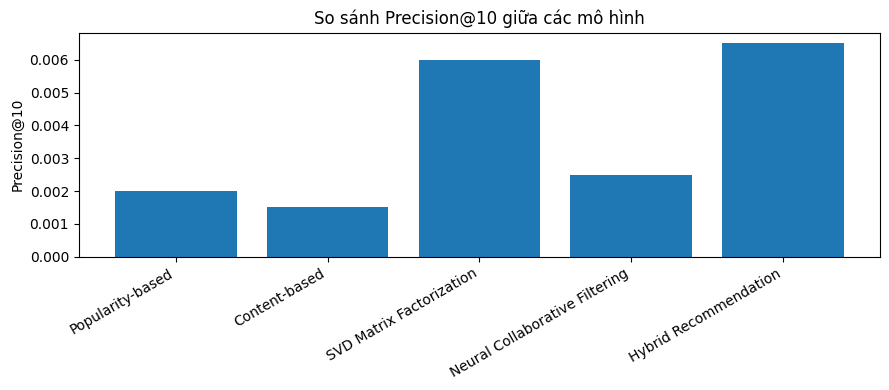

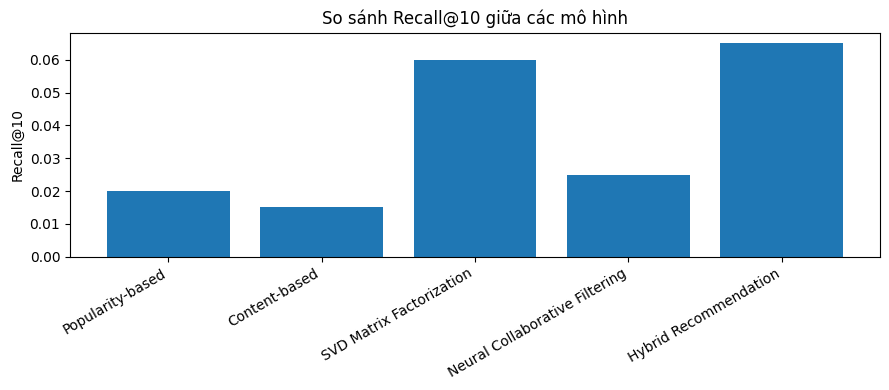

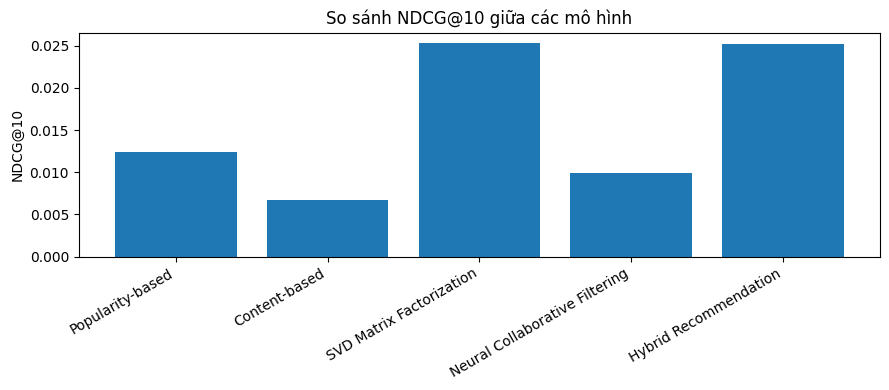

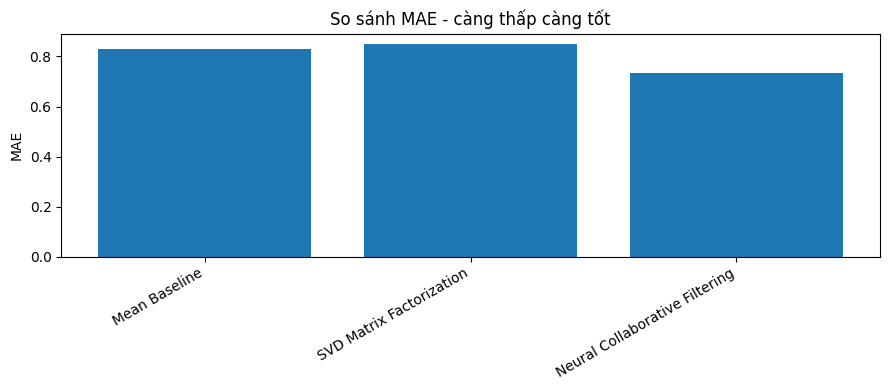

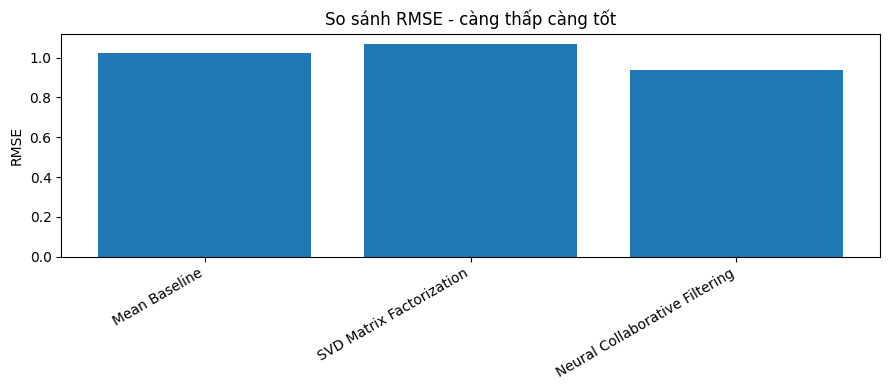

In [ ]:
# 24. Tổng hợp và so sánh kết quả mô hình

results = [
    {
        'Model': 'Mean Baseline',
        'MAE': mae_baseline,
        'RMSE': rmse_baseline,
        'Precision@10': np.nan,
        'Recall@10': np.nan,
        'NDCG@10': np.nan,
        'Users_Evaluated': np.nan
    },
    {
        'Model': 'Popularity-based',
        'MAE': np.nan,
        'RMSE': np.nan,
        **metrics_popularity_topn
    },
    {
        'Model': 'Content-based',
        'MAE': np.nan,
        'RMSE': np.nan,
        **metrics_content_topn
    },
    {
        'Model': 'SVD Matrix Factorization',
        'MAE': mae_svd,
        'RMSE': rmse_svd,
        **metrics_svd_topn
    },
    {
        'Model': (
            'Neural Collaborative Filtering'
        ),
        'MAE': mae_nn,
        'RMSE': rmse_nn,
        **metrics_nn_topn
    },
    {
        'Model': 'Hybrid Recommendation',
        'MAE': np.nan,
        'RMSE': np.nan,
        **metrics_hybrid_topn
    }
]

results_df = pd.DataFrame(
    results
)

display(results_df)

rating_rows = results_df.dropna(
    subset=['RMSE']
)

topn_rows = results_df.dropna(
    subset=['NDCG@10']
)

best_rating_row = rating_rows.loc[
    rating_rows['RMSE'].idxmin()
]

best_topn_row = topn_rows.loc[
    topn_rows['NDCG@10'].idxmax()
]

print(
    'MAE/RMSE càng thấp càng tốt.'
)

print(
    'Precision/Recall/NDCG càng cao càng tốt.'
)

print(
    f"Mô hình dự đoán rating tốt nhất: "
    f"{best_rating_row['Model']} "
    f"(RMSE = {best_rating_row['RMSE']:.4f})"
)

print(
    f"Mô hình xếp hạng Top-10 tốt nhất: "
    f"{best_topn_row['Model']} "
    f"(NDCG@10 = {best_topn_row['NDCG@10']:.4f})"
)

if rmse_nn < rmse_svd:
    improvement_pct = (
        (rmse_svd - rmse_nn)
        / rmse_svd
        * 100
    )

    print(
        f'Neural Network giảm RMSE '
        f'{improvement_pct:.2f}% so với SVD.'
    )
else:
    worse_pct = (
        (rmse_nn - rmse_svd)
        / rmse_svd
        * 100
    )

    print(
        f'Neural Network có RMSE cao hơn '
        f'SVD {worse_pct:.2f}%.'
    )

# Biểu đồ Top-N
for metric in [
    'Precision@10',
    'Recall@10',
    'NDCG@10'
]:
    temp = (
        results_df[
            ['Model', metric]
        ]
        .dropna()
    )

    plt.figure(figsize=(9, 4))

    plt.bar(
        temp['Model'],
        temp[metric]
    )

    plt.title(
        f'So sánh {metric} giữa các mô hình'
    )

    plt.ylabel(metric)

    plt.xticks(
        rotation=30,
        ha='right'
    )

    plt.tight_layout()
    plt.show()

# Biểu đồ MAE và RMSE
for metric in [
    'MAE',
    'RMSE'
]:
    temp = (
        results_df[
            ['Model', metric]
        ]
        .dropna()
    )

    plt.figure(figsize=(9, 4))

    plt.bar(
        temp['Model'],
        temp[metric]
    )

    plt.title(
        f'So sánh {metric} '
        f'- càng thấp càng tốt'
    )

    plt.ylabel(metric)

    plt.xticks(
        rotation=30,
        ha='right'
    )

    plt.tight_layout()
    plt.show()


## 25. Demo tổng hợp hệ thống gợi ý

### Chức năng

Với một `UserID`, demo hiển thị:

1. Lịch sử các phim được người dùng đánh giá cao.
2. Danh sách Popularity-based.
3. Danh sách Content-based.
4. Danh sách SVD.
5. Danh sách Neural Network.
6. Danh sách Hybrid.

### Mục đích

Giúp quan sát sự khác biệt giữa mô hình không cá nhân hoá và các mô hình cá nhân hoá trên cùng một người dùng.


### Đầu vào

Demo chỉ yêu cầu `UserID`. Từ ID này, từng mô hình tự tạo các đặc trưng hoặc điểm cần thiết; người dùng không phải nhập `Gender`, `Age`, `Occupation`, `ZipCode` hay rating thật.


In [ ]:
# 25. Hàm demo tổng hợp

def show_user_history(user_id, n=10):
    history = ratings_movies[ratings_movies['UserID'] == user_id].sort_values('Rating', ascending=False)
    return history[['UserID', 'MovieID', 'Title', 'Genres', 'Rating']].head(n)

def demo_recommend_for_user(user_id, top_n=10):
    print(f'Lịch sử rating cao của UserID = {user_id}')
    display(show_user_history(user_id, 10))

    print('\nGợi ý Popularity-based')
    display(recommend_popular(top_n))

    print('\nGợi ý Content-based')
    display(recommend_content_based(user_id, top_n))

    print('\nGợi ý SVD')
    display(recommend_svd(user_id, top_n))

    print('\nGợi ý Neural Network')
    display(recommend_neural_network(user_id, top_n))

    print('\nGợi ý Hybrid')
    display(recommend_hybrid(user_id, top_n))

# Chạy demo
user_demo = 1
demo_recommend_for_user(user_demo, 10)


Lịch sử rating cao của UserID = 1


,UserID,MovieID,Title,Genres,Rating
0,1,1193,One Flew Over the Cuckoo's Nest (1975),Drama,5
4,1,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,5
10,1,595,Beauty and the Beast (1991),Animation|Children's|Musical,5
7,1,2804,"Christmas Story, A (1983)",Comedy|Drama,5
6,1,1287,Ben-Hur (1959),Action|Adventure|Drama,5
18,1,3105,Awakenings (1990),Drama,5
14,1,1035,"Sound of Music, The (1965)",Musical,5
40,1,1,Toy Story (1995),Animation|Children's|Comedy,5
41,1,1961,Rain Man (1988),Drama,5
36,1,1836,"Last Days of Disco, The (1998)",Drama,5



Gợi ý Popularity-based


,MovieID,Title,Genres,rating_count,rating_mean,popularity_score
309,318,"Shawshank Redemption, The (1994)",Drama,2198,4.553230,4.420732
802,858,"Godfather, The (1972)",Action|Crime|Drama,2204,4.524047,4.395830
513,527,Schindler's List (1993),Drama|War,2277,4.509442,4.386724
1108,1198,Raiders of the Lost Ark (1981),Action|Adventure,2498,4.476381,4.367228
49,50,"Usual Suspects, The (1995)",Crime|Thriller,1764,4.519841,4.365591
253,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,2974,4.452925,4.361868
2556,2762,"Sixth Sense, The (1999)",Thriller,2404,4.408486,4.304167
713,750,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,1358,4.446981,4.270829
851,912,Casablanca (1942),Drama|Romance|War,1655,4.412689,4.268613
579,593,"Silence of the Lambs, The (1991)",Drama|Thriller,2562,4.351288,4.259458



Gợi ý Content-based


...

,MovieID,svd_score,Title,Genres
120,356,4.437211,Forrest Gump (1994),Comedy|Romance|War
41,110,4.367256,Braveheart (1995),Action|Drama|War
339,364,4.320595,"Lion King, The (1994)",Animation|Children's|Musical
62,480,4.319519,Jurassic Park (1993),Action|Adventure|Sci-Fi
185,1250,4.295337,"Bridge on the River Kwai, The (1957)",Drama|War
156,2081,4.292903,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance
72,590,4.289319,Dances with Wolves (1990),Adventure|Drama|Western
355,3753,4.288608,"Patriot, The (2000)",Action|Drama|War
162,1387,4.284691,Jaws (1975),Action|Horror
1488,1272,4.282897,Patton (1970),Drama|War



Gợi ý Neural Network


,MovieID,nn_score,Title,Genres
0,318,4.763237,"Shawshank Redemption, The (1994)",Drama
1,1198,4.710939,Raiders of the Lost Ark (1981),Action|Adventure
2,2905,4.662695,Sanjuro (1962),Action|Adventure
3,50,4.611957,"Usual Suspects, The (1995)",Crime|Thriller
4,1250,4.611765,"Bridge on the River Kwai, The (1957)",Drama|War
5,1148,4.606110,"Wrong Trousers, The (1993)",Animation|Comedy
6,593,4.601793,"Silence of the Lambs, The (1991)",Drama|Thriller
7,1262,4.595941,"Great Escape, The (1963)",Adventure|War
8,953,4.587449,It's a Wonderful Life (1946),Drama
9,2019,4.575666,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama



Gợi ý Hybrid


,MovieID,svd_norm,content_norm,pop_norm,hybrid_score,Title,Genres
0,318,0.810692,0.739227,1.000000,0.815330,"Shawshank Redemption, The (1994)",Drama
1,953,0.817109,0.739227,0.807360,0.800558,It's a Wonderful Life (1946),Drama
2,34,0.807071,0.828191,0.683068,0.798895,Babe (1995),Children's|Comedy|Drama
3,2324,0.805168,0.742100,0.855736,0.797612,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama
4,923,0.799338,0.739227,0.878534,0.795235,Citizen Kane (1941),Drama
5,1704,0.806745,0.739227,0.807988,0.793366,Good Will Hunting (1997),Drama
6,1203,0.808421,0.739227,0.791711,0.792911,12 Angry Men (1957),Drama
7,1276,0.802805,0.742100,0.808126,0.791196,Cool Hand Luke (1967),Comedy|Drama
8,1225,0.798927,0.739227,0.836679,0.790762,Amadeus (1984),Drama
9,3363,0.812055,0.742100,0.723540,0.789213,American Graffiti (1973),Comedy|Drama


## 26. Demo dự đoán rating cụ thể

### Mục đích

Kiểm thử tình huống người dùng cụ thể và bộ phim cụ thể.

Hàm `predict_rating_demo(user_id, movie_id)`:

- Tìm thông tin phim.
- Gọi cả `predict_svd` và `predict_neural_rating`.
- Hiển thị hai rating dự đoán trên thang điểm 5 để so sánh.

Ví dụ trong code dự đoán rating của `UserID = 1` đối với `MovieID = 1193`.


### Đầu vào

Đầu vào là cặp `user_id`, `movie_id`. Rating thật không được truyền vào hàm; nó chỉ cần khi đánh giá độ chính xác trên tập test.


In [ ]:
# 26. Dự đoán rating cho một user và một movie cụ thể

def predict_rating_demo(user_id, movie_id):
    movie_info = movies_clean[movies_clean['MovieID'] == movie_id][['MovieID', 'Title', 'Genres']]
    pred_svd = predict_svd(user_id, movie_id)
    pred_nn = predict_neural_rating(user_id, movie_id)
    print(f'UserID: {user_id}')
    display(movie_info)
    print(f'Rating dự đoán theo SVD: {pred_svd:.2f}/5')
    print(f'Rating dự đoán theo Neural Network: {pred_nn:.2f}/5')

predict_rating_demo(user_id=1, movie_id=1193)


UserID: 1


,MovieID,Title,Genres
1176,1193,One Flew Over the Cuckoo's Nest (1975),Drama


Rating dự đoán theo SVD: 4.31/5
Rating dự đoán theo Neural Network: 4.54/5


## 27. Xuất kết quả ra file CSV

### Mục đích

Lưu các bảng quan trọng để sử dụng trong báo cáo, phụ lục hoặc tích hợp với hệ thống khác.

### Các file được tạo

| File | Nội dung |
|---|---|
| `top10_recommend_user1.csv` | Top 10 phim Hybrid cho UserID 1 |
| `model_evaluation_results.csv` | Bảng so sánh các mô hình |
| `movies_clean.csv` | Dữ liệu phim sau tiền xử lý |

Các file được lưu trong thư mục `/content` của Google Colab.


In [ ]:
# 27. Xuất kết quả ra file CSV

OUTPUT_DIR = (
    '/content'
    if os.path.exists('/content')
    else './outputs'
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

top10_path = os.path.join(
    OUTPUT_DIR,
    'top10_recommend_user1.csv'
)

evaluation_path = os.path.join(
    OUTPUT_DIR,
    'model_evaluation_results.csv'
)

movies_path = os.path.join(
    OUTPUT_DIR,
    'movies_clean.csv'
)

recommend_hybrid(
    user_id=1,
    top_n=10
).to_csv(
    top10_path,
    index=False,
    encoding='utf-8-sig'
)

results_df.to_csv(
    evaluation_path,
    index=False,
    encoding='utf-8-sig'
)

movies_clean.to_csv(
    movies_path,
    index=False,
    encoding='utf-8-sig'
)

print('Đã xuất file:')
print(top10_path)
print(evaluation_path)
print(movies_path)


Đã xuất file:
/content/top10_recommend_user1.csv
/content/model_evaluation_results.csv
/content/movies_clean.csv


## 28. Lưu model để tái sử dụng

### Mục đích

Sau khi huấn luyện, các thành phần quan trọng được lưu lại để không phải chạy lại toàn bộ quy trình mỗi lần sử dụng.

### Các file được lưu

| File | Nội dung |
|---|---|
| `svd_factors.npz` | Các ma trận SVD, user mean, BEST_K và global mean |
| `content_features.npz` | Ma trận đặc trưng thể loại và danh sách MovieID |
| `neural_cf.keras` | Kiến trúc và trọng số Neural Collaborative Filtering |
| `recommender_artifacts.pkl` | Mapping, metadata phim, popularity score, trọng số Hybrid, danh sách phim đã xem và `user_content_profiles` |
| `movie_recommender_model.zip` | File nén toàn bộ model |

### Tối ưu dung lượng

Notebook chỉ lưu các factor SVD tốt nhất thay vì lưu toàn bộ `pred_matrix`, vì ma trận dự đoán đầy đủ có thể rất lớn.

### Kết quả mong đợi

Thư mục `/content/movie_recommender_model` và file `/content/movie_recommender_model.zip` được tạo thành công.


### Thành phần cần đi cùng model

Trọng số mô hình không đủ để dự đoán nếu thiếu mapping và quy tắc tiền xử lý. Vì vậy phải lưu đồng thời `user_to_idx`, `movie_to_idx`, feature matrix, danh sách `genre_cols`, các user profile và thông tin chuẩn hóa điểm.


In [ ]:
# 28. Lưu model và artifacts để tái sử dụng

import os
import pickle
import zipfile
import shutil
import numpy as np


MODEL_DIR = '/content/movie_recommender_model'
ZIP_PATH = '/content/movie_recommender_model.zip'


# Xóa model cũ để tránh giữ lại file lỗi thời
if os.path.exists(MODEL_DIR):
    shutil.rmtree(MODEL_DIR)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# =========================================================
# 1. Lưu SVD factors
# =========================================================

U_best = U_full[:, :BEST_K].astype(
    np.float32
)

sigma_best = (
    singular_values_full[:BEST_K]
    .astype(np.float32)
)

Vt_best = Vt_full[:BEST_K, :].astype(
    np.float32
)


np.savez_compressed(
    os.path.join(
        MODEL_DIR,
        'svd_factors.npz'
    ),
    U=U_best,
    sigma=sigma_best,
    Vt=Vt_best,
    user_mean_vector=(
        user_mean_vector.astype(np.float32)
    ),
    best_k=np.array(
        [BEST_K],
        dtype=np.int32
    ),
    global_mean=np.array(
        [GLOBAL_MEAN],
        dtype=np.float32
    )
)


# =========================================================
# 2. Lưu đặc trưng Content-based
# =========================================================

movie_feature_ids = np.array(
    movie_feature_df.index.tolist(),
    dtype=np.int64
)


np.savez_compressed(
    os.path.join(
        MODEL_DIR,
        'content_features.npz'
    ),
    movie_feature_matrix=(
        movie_feature_matrix.astype(
            np.float32
        )
    ),
    movie_feature_ids=movie_feature_ids
)


# =========================================================
# 3. Lưu Neural Collaborative Filtering
# =========================================================

nn_model.save(
    os.path.join(
        MODEL_DIR,
        'neural_cf.keras'
    )
)


# =========================================================
# 4. Lưu danh sách phim đã xem
# =========================================================

train_user_items = (
    train_df
    .groupby('UserID')['MovieID']
    .apply(lambda values: set(values))
    .to_dict()
)


# =========================================================
# 5. Tạo Content profile cho từng user
# =========================================================

user_content_profiles = {}

unique_train_users = (
    train_df['UserID']
    .drop_duplicates()
    .tolist()
)


for index, user_id in enumerate(
    unique_train_users,
    start=1
):

    profile = build_user_profile(user_id)

    if (
        profile is not None
        and np.linalg.norm(profile) > 0
    ):
        user_content_profiles[user_id] = (
            np.asarray(
                profile,
                dtype=np.float32
            )
        )

    if index % 500 == 0:
        print(
            f'Đã tạo profile cho '
            f'{index}/{len(unique_train_users)} user'
        )


print(
    'Số Content profile đã tạo:',
    len(user_content_profiles)
)


# =========================================================
# 6. Lưu metadata và cấu hình
# =========================================================

artifacts = {
    'user_to_idx': user_to_idx,
    'movie_to_idx': movie_to_idx,

    'unique_users': list(unique_users),
    'unique_movies': list(unique_movies),

    'movies_clean': movies_clean[
        [
            'MovieID',
            'Title',
            'Genres'
        ]
    ].copy(),

    'movie_pop': movie_pop.copy(),

    'genre_cols': genre_cols,

    'movie_feature_id_to_pos': (
        movie_feature_id_to_pos
    ),

    'train_user_items': train_user_items,

    # Quan trọng:
    # dùng để phục hồi Content-based
    # sau khi load model
    'user_content_profiles': (
        user_content_profiles
    ),

    'GLOBAL_MEAN': float(GLOBAL_MEAN),

    'user_mean': user_mean,
    'movie_mean': movie_mean,

    'C': float(C),
    'm': float(m),

    'pop_min': float(pop_min),
    'pop_max': float(pop_max),

    'pop_score_map': pop_score_map,

    'DEFAULT_HYBRID_WEIGHTS': (
        DEFAULT_HYBRID_WEIGHTS
    ),

    'BEST_HYBRID_WEIGHTS': (
        BEST_HYBRID_WEIGHTS
    ),

    'BEST_K': int(BEST_K)
}


with open(
    os.path.join(
        MODEL_DIR,
        'recommender_artifacts.pkl'
    ),
    'wb'
) as file:
    pickle.dump(
        artifacts,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )


# =========================================================
# 7. Kiểm tra file đã lưu
# =========================================================

required_files = [
    'svd_factors.npz',
    'content_features.npz',
    'neural_cf.keras',
    'recommender_artifacts.pkl'
]


for filename in required_files:

    filepath = os.path.join(
        MODEL_DIR,
        filename
    )

    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f'Không thể tạo file: {filename}'
        )


# =========================================================
# 8. Nén toàn bộ model
# =========================================================

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)


with zipfile.ZipFile(
    ZIP_PATH,
    'w',
    zipfile.ZIP_DEFLATED
) as zip_file:

    for root, _, files in os.walk(
        MODEL_DIR
    ):

        for filename in files:

            file_path = os.path.join(
                root,
                filename
            )

            archive_name = os.path.relpath(
                file_path,
                MODEL_DIR
            )

            zip_file.write(
                file_path,
                archive_name
            )


print('\nĐã lưu model tại:')
print(MODEL_DIR)

print('\nFile ZIP:')
print(ZIP_PATH)

print('\nCác file đã lưu:')

for filename in os.listdir(MODEL_DIR):

    filepath = os.path.join(
        MODEL_DIR,
        filename
    )

    file_size_mb = (
        os.path.getsize(filepath)
        / (1024 * 1024)
    )

    print(
        f'- {filename}: '
        f'{file_size_mb:.2f} MB'
    )

Đã tạo profile cho 500/6040 user
Đã tạo profile cho 1000/6040 user
Đã tạo profile cho 1500/6040 user
Đã tạo profile cho 2000/6040 user
Đã tạo profile cho 2500/6040 user
Đã tạo profile cho 3000/6040 user
Đã tạo profile cho 3500/6040 user
Đã tạo profile cho 4000/6040 user
Đã tạo profile cho 4500/6040 user
Đã tạo profile cho 5000/6040 user
Đã tạo profile cho 5500/6040 user
Đã tạo profile cho 6000/6040 user
Số Content profile đã tạo: 6038

Đã lưu model tại:
/content/movie_recommender_model

File ZIP:
/content/movie_recommender_model.zip

Các file đã lưu:
- recommender_artifacts.pkl: 4.29 MB
- neural_cf.keras: 3.81 MB
- svd_factors.npz: 1.76 MB
- content_features.npz: 0.02 MB


## 29. Load model đã lưu và dùng thử

### Mục đích

Khôi phục hệ thống gợi ý trong một phiên Colab hoặc ứng dụng mới mà không cần train lại.

### Quy trình

1. Giải nén `movie_recommender_model.zip` nếu thư mục model chưa tồn tại.
2. Đọc metadata và mapping từ file pickle.
3. Đọc factor SVD và content feature matrix từ file NPZ.
4. Load Neural Network từ `neural_cf.keras`.
5. Khôi phục các hàm Baseline, SVD, Neural CF và Hybrid.
6. Chạy thử dự đoán và danh sách gợi ý sau khi load.

### Hybrid sau khi load

Code lưu `user_content_profiles` trong `recommender_artifacts.pkl`, vì vậy thành phần Content-based của Hybrid **được khôi phục đầy đủ**, không bị đặt bằng 0. Cell kiểm tra phía sau so sánh Hybrid trước và sau khi lưu để xác nhận danh sách, thứ tự và điểm gần như giống nhau.

### Đầu vào khi sử dụng model đã load

- Dự đoán rating: `user_id`, `movie_id`.
- Gợi ý SVD/Neural/Hybrid: `user_id`, `top_n`.
- Các mapping và feature matrix được đọc từ artifacts, người dùng không phải truyền lại các cột dữ liệu gốc.


In [ ]:
# 29. Load model đã lưu và sử dụng lại

import os
import pickle
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics.pairwise import (
    cosine_similarity
)


MODEL_DIR = '/content/movie_recommender_model'
ZIP_PATH = '/content/movie_recommender_model.zip'


# =========================================================
# 1. Giải nén nếu chưa có thư mục model
# =========================================================

if (
    not os.path.exists(MODEL_DIR)
    and os.path.exists(ZIP_PATH)
):

    os.makedirs(
        MODEL_DIR,
        exist_ok=True
    )

    with zipfile.ZipFile(
        ZIP_PATH,
        'r'
    ) as zip_file:

        zip_file.extractall(
            MODEL_DIR
        )


# =========================================================
# 2. Kiểm tra file model
# =========================================================

required_files = [
    'recommender_artifacts.pkl',
    'svd_factors.npz',
    'content_features.npz',
    'neural_cf.keras'
]


missing_files = [
    filename
    for filename in required_files
    if not os.path.exists(
        os.path.join(
            MODEL_DIR,
            filename
        )
    )
]


if missing_files:
    raise FileNotFoundError(
        'Thiếu các file model: '
        + ', '.join(missing_files)
    )


# =========================================================
# 3. Load artifacts
# =========================================================

with open(
    os.path.join(
        MODEL_DIR,
        'recommender_artifacts.pkl'
    ),
    'rb'
) as file:

    loaded_artifacts = pickle.load(file)


# =========================================================
# 4. Load SVD
# =========================================================

svd_data = np.load(
    os.path.join(
        MODEL_DIR,
        'svd_factors.npz'
    )
)

loaded_U = svd_data['U']
loaded_sigma = svd_data['sigma']
loaded_Vt = svd_data['Vt']

loaded_user_mean_vector = (
    svd_data['user_mean_vector']
)


# =========================================================
# 5. Load Content-based features
# =========================================================

content_data = np.load(
    os.path.join(
        MODEL_DIR,
        'content_features.npz'
    )
)

loaded_movie_feature_matrix = (
    content_data['movie_feature_matrix']
)

loaded_movie_feature_ids = (
    content_data['movie_feature_ids']
)


# =========================================================
# 6. Load Neural Network
# =========================================================

loaded_nn_model = (
    tf.keras.models.load_model(
        os.path.join(
            MODEL_DIR,
            'neural_cf.keras'
        )
    )
)


# =========================================================
# 7. Mean Baseline
# =========================================================

def loaded_predict_baseline(
    user_id,
    movie_id
):
    global_mean = (
        loaded_artifacts['GLOBAL_MEAN']
    )

    loaded_user_mean = (
        loaded_artifacts['user_mean']
        .get(
            user_id,
            global_mean
        )
    )

    loaded_movie_mean = (
        loaded_artifacts['movie_mean']
        .get(
            movie_id,
            global_mean
        )
    )

    prediction = (
        0.5 * loaded_movie_mean
        + 0.3 * loaded_user_mean
        + 0.2 * global_mean
    )

    return float(
        np.clip(
            prediction,
            1.0,
            5.0
        )
    )


# =========================================================
# 8. Dự đoán SVD
# =========================================================

def loaded_predict_svd(
    user_id,
    movie_id
):
    user_to_idx_loaded = (
        loaded_artifacts['user_to_idx']
    )

    movie_to_idx_loaded = (
        loaded_artifacts['movie_to_idx']
    )

    if (
        user_id not in user_to_idx_loaded
        or movie_id not in movie_to_idx_loaded
    ):
        return loaded_predict_baseline(
            user_id,
            movie_id
        )

    user_index = user_to_idx_loaded[
        user_id
    ]

    movie_index = movie_to_idx_loaded[
        movie_id
    ]

    residual = (
        loaded_U[user_index]
        * loaded_sigma
    ) @ loaded_Vt[:, movie_index]

    prediction = (
        residual
        + loaded_user_mean_vector[
            user_index
        ]
    )

    return float(
        np.clip(
            prediction,
            1.0,
            5.0
        )
    )


# =========================================================
# 9. Gợi ý bằng SVD
# =========================================================

def loaded_recommend_svd(
    user_id,
    top_n=10
):
    user_to_idx_loaded = (
        loaded_artifacts['user_to_idx']
    )

    movie_to_idx_loaded = (
        loaded_artifacts['movie_to_idx']
    )

    movies_metadata = (
        loaded_artifacts['movies_clean']
    )

    if user_id not in user_to_idx_loaded:
        return (
            loaded_artifacts['movie_pop']
            .sort_values(
                'popularity_score',
                ascending=False
            )
            .head(top_n)
        )

    user_index = user_to_idx_loaded[
        user_id
    ]

    user_scores = (
        loaded_U[user_index]
        * loaded_sigma
    ) @ loaded_Vt

    user_scores = (
        user_scores
        + loaded_user_mean_vector[
            user_index
        ]
    )

    watched = (
        loaded_artifacts[
            'train_user_items'
        ]
        .get(
            user_id,
            set()
        )
    )

    rows = []

    for (
        movie_id,
        movie_index
    ) in movie_to_idx_loaded.items():

        if movie_id in watched:
            continue

        prediction = float(
            np.clip(
                user_scores[movie_index],
                1.0,
                5.0
            )
        )

        rows.append({
            'MovieID': movie_id,
            'svd_score': prediction
        })

    recommendations = pd.DataFrame(rows)

    recommendations = recommendations.merge(
        movies_metadata,
        on='MovieID',
        how='left'
    )

    return (
        recommendations
        .sort_values(
            'svd_score',
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


# =========================================================
# 10. Dự đoán Neural Network
# =========================================================

def loaded_predict_nn(
    user_id,
    movie_id
):
    user_to_idx_loaded = (
        loaded_artifacts['user_to_idx']
    )

    movie_to_idx_loaded = (
        loaded_artifacts['movie_to_idx']
    )

    if (
        user_id not in user_to_idx_loaded
        or movie_id not in movie_to_idx_loaded
    ):
        return loaded_predict_baseline(
            user_id,
            movie_id
        )

    user_index = np.array(
        [[user_to_idx_loaded[user_id]]],
        dtype=np.int32
    )

    movie_index = np.array(
        [[movie_to_idx_loaded[movie_id]]],
        dtype=np.int32
    )

    prediction_scaled = loaded_nn_model(
        [
            user_index,
            movie_index
        ],
        training=False
    ).numpy().reshape(-1)[0]

    prediction = (
        1.0
        + 4.0 * prediction_scaled
    )

    return float(
        np.clip(
            prediction,
            1.0,
            5.0
        )
    )


# =========================================================
# 11. Gợi ý bằng Neural Network
# =========================================================

def loaded_recommend_nn(
    user_id,
    top_n=10
):
    user_to_idx_loaded = (
        loaded_artifacts['user_to_idx']
    )

    movie_to_idx_loaded = (
        loaded_artifacts['movie_to_idx']
    )

    movies_metadata = (
        loaded_artifacts['movies_clean']
    )

    if user_id not in user_to_idx_loaded:
        return (
            loaded_artifacts['movie_pop']
            .sort_values(
                'popularity_score',
                ascending=False
            )
            .head(top_n)
        )

    watched = (
        loaded_artifacts[
            'train_user_items'
        ]
        .get(
            user_id,
            set()
        )
    )

    candidate_movie_ids = [
        movie_id
        for movie_id
        in movie_to_idx_loaded
        if movie_id not in watched
    ]

    movie_indices = np.array(
        [
            movie_to_idx_loaded[
                movie_id
            ]
            for movie_id
            in candidate_movie_ids
        ],
        dtype=np.int32
    ).reshape(-1, 1)

    user_indices = np.full(
        (
            len(candidate_movie_ids),
            1
        ),
        user_to_idx_loaded[user_id],
        dtype=np.int32
    )

    prediction_scaled = loaded_nn_model(
        [
            user_indices,
            movie_indices
        ],
        training=False
    ).numpy().reshape(-1)

    predicted_ratings = np.clip(
        1.0 + 4.0 * prediction_scaled,
        1.0,
        5.0
    )

    recommendations = pd.DataFrame({
        'MovieID': candidate_movie_ids,
        'nn_score': predicted_ratings
    })

    recommendations = recommendations.merge(
        movies_metadata,
        on='MovieID',
        how='left'
    )

    return (
        recommendations
        .sort_values(
            'nn_score',
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


# =========================================================
# 12. Gợi ý Hybrid đầy đủ sau khi load
# =========================================================

def loaded_recommend_hybrid(
    user_id,
    top_n=10
):
    user_to_idx_loaded = (
        loaded_artifacts['user_to_idx']
    )

    movie_to_idx_loaded = (
        loaded_artifacts['movie_to_idx']
    )

    movie_feature_position = (
        loaded_artifacts[
            'movie_feature_id_to_pos'
        ]
    )

    movies_metadata = (
        loaded_artifacts['movies_clean']
    )

    user_content_profiles = (
        loaded_artifacts.get(
            'user_content_profiles',
            {}
        )
    )

    alpha, beta, gamma = (
        loaded_artifacts[
            'BEST_HYBRID_WEIGHTS'
        ]
    )

    loaded_pop_score_map = (
        loaded_artifacts[
            'pop_score_map'
        ]
    )

    loaded_pop_min = (
        loaded_artifacts['pop_min']
    )

    loaded_pop_max = (
        loaded_artifacts['pop_max']
    )

    if user_id not in user_to_idx_loaded:
        return (
            loaded_artifacts['movie_pop']
            .sort_values(
                'popularity_score',
                ascending=False
            )
            .head(top_n)
        )

    watched = (
        loaded_artifacts[
            'train_user_items'
        ]
        .get(
            user_id,
            set()
        )
    )

    user_index = user_to_idx_loaded[
        user_id
    ]

    # Điểm SVD cho toàn bộ phim
    svd_scores = (
        loaded_U[user_index]
        * loaded_sigma
    ) @ loaded_Vt

    svd_scores = (
        svd_scores
        + loaded_user_mean_vector[
            user_index
        ]
    )

    # Lấy Content profile đã lưu
    user_profile = (
        user_content_profiles.get(
            user_id
        )
    )

    if (
        user_profile is not None
        and np.linalg.norm(
            user_profile
        ) > 0
    ):
        content_scores_all = (
            cosine_similarity(
                user_profile.reshape(
                    1,
                    -1
                ),
                loaded_movie_feature_matrix
            )[0]
        )
    else:
        content_scores_all = np.zeros(
            len(
                loaded_movie_feature_ids
            ),
            dtype=np.float32
        )

    rows = []

    for (
        movie_id,
        movie_index
    ) in movie_to_idx_loaded.items():

        if movie_id in watched:
            continue

        # SVD
        svd_rating = np.clip(
            svd_scores[movie_index],
            1.0,
            5.0
        )

        svd_norm = (
            svd_rating - 1.0
        ) / 4.0

        svd_norm = float(
            np.clip(
                svd_norm,
                0.0,
                1.0
            )
        )

        # Content-based
        if movie_id in movie_feature_position:

            feature_index = (
                movie_feature_position[
                    movie_id
                ]
            )

            content_norm = float(
                content_scores_all[
                    feature_index
                ]
            )

        else:
            content_norm = 0.0

        content_norm = float(
            np.clip(
                content_norm,
                0.0,
                1.0
            )
        )

        # Popularity
        popularity_value = (
            loaded_pop_score_map.get(
                movie_id,
                loaded_artifacts['C']
            )
        )

        pop_norm = (
            popularity_value
            - loaded_pop_min
        ) / (
            loaded_pop_max
            - loaded_pop_min
            + 1e-9
        )

        pop_norm = float(
            np.clip(
                pop_norm,
                0.0,
                1.0
            )
        )

        # Hybrid score
        hybrid_score = (
            alpha * svd_norm
            + beta * content_norm
            + gamma * pop_norm
        )

        rows.append({
            'MovieID': movie_id,
            'svd_norm': svd_norm,
            'content_norm': content_norm,
            'pop_norm': pop_norm,
            'hybrid_score': float(
                hybrid_score
            )
        })

    recommendations = pd.DataFrame(rows)

    recommendations = recommendations.merge(
        movies_metadata,
        on='MovieID',
        how='left'
    )

    return (
        recommendations
        .sort_values(
            'hybrid_score',
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


# =========================================================
# 13. Kiểm thử
# =========================================================

print('Load model thành công.')

print(
    'BEST_K:',
    loaded_artifacts['BEST_K']
)

print(
    'Trọng số Hybrid:',
    loaded_artifacts[
        'BEST_HYBRID_WEIGHTS'
    ]
)

print(
    'Số Content profile:',
    len(
        loaded_artifacts.get(
            'user_content_profiles',
            {}
        )
    )
)


print('\nTop-N theo SVD:')

display(
    loaded_recommend_svd(
        user_id=1,
        top_n=10
    )
)


print('\nTop-N theo Neural Network:')

display(
    loaded_recommend_nn(
        user_id=1,
        top_n=10
    )
)

print('\nTop-N theo Hybrid:')

display(
    loaded_recommend_hybrid(
        user_id=1,
        top_n=10
    )
)

Load model thành công.
BEST_K: 50
Trọng số Hybrid: (0.7, 0.2, 0.1)
Số Content profile: 6038

Top-N theo SVD:


,MovieID,svd_score,Title,Genres
0,356,4.437212,Forrest Gump (1994),Comedy|Romance|War
1,110,4.367256,Braveheart (1995),Action|Drama|War
2,364,4.320595,"Lion King, The (1994)",Animation|Children's|Musical
3,480,4.319519,Jurassic Park (1993),Action|Adventure|Sci-Fi
4,1250,4.295337,"Bridge on the River Kwai, The (1957)",Drama|War
5,2081,4.292903,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance
6,590,4.289319,Dances with Wolves (1990),Adventure|Drama|Western
7,3753,4.288609,"Patriot, The (2000)",Action|Drama|War
8,1387,4.284691,Jaws (1975),Action|Horror
9,1272,4.282897,Patton (1970),Drama|War



Top-N theo Neural Network:


,MovieID,nn_score,Title,Genres
0,318,4.763237,"Shawshank Redemption, The (1994)",Drama
1,1198,4.710939,Raiders of the Lost Ark (1981),Action|Adventure
2,2905,4.662695,Sanjuro (1962),Action|Adventure
3,50,4.611957,"Usual Suspects, The (1995)",Crime|Thriller
4,1250,4.611765,"Bridge on the River Kwai, The (1957)",Drama|War
5,1148,4.606110,"Wrong Trousers, The (1993)",Animation|Comedy
6,593,4.601793,"Silence of the Lambs, The (1991)",Drama|Thriller
7,1262,4.595941,"Great Escape, The (1963)",Adventure|War
8,953,4.587449,It's a Wonderful Life (1946),Drama
9,2019,4.575666,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama



Top-N theo Hybrid:


,MovieID,svd_norm,content_norm,pop_norm,hybrid_score,Title,Genres
0,318,0.810692,0.739227,1.000000,0.815330,"Shawshank Redemption, The (1994)",Drama
1,953,0.817109,0.739227,0.807360,0.800558,It's a Wonderful Life (1946),Drama
2,34,0.807071,0.828191,0.683068,0.798895,Babe (1995),Children's|Comedy|Drama
3,2324,0.805168,0.742101,0.855736,0.797612,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama
4,923,0.799338,0.739227,0.878534,0.795235,Citizen Kane (1941),Drama
5,1704,0.806745,0.739227,0.807988,0.793366,Good Will Hunting (1997),Drama
6,1203,0.808421,0.739227,0.791711,0.792911,12 Angry Men (1957),Drama
7,1276,0.802805,0.742101,0.808126,0.791196,Cool Hand Luke (1967),Comedy|Drama
8,1225,0.798927,0.739227,0.836679,0.790762,Amadeus (1984),Drama
9,3363,0.812055,0.742101,0.723540,0.789213,American Graffiti (1973),Comedy|Drama


# Kiểm tra kết quả Hybrid trước và sau khi lưu

Mục tiêu là xác nhận việc lưu/load không làm mất `user_content_profiles` hoặc thay đổi cách chuẩn hóa ba thành phần `svd_norm`, `content_norm`, `pop_norm`.


In [ ]:
# Kiểm tra kết quả Hybrid trước và sau khi lưu

original_hybrid = (
    recommend_hybrid(
        user_id=1,
        top_n=10
    )[
        [
            'MovieID',
            'Title',
            'hybrid_score'
        ]
    ]
    .reset_index(drop=True)
)

loaded_hybrid = (
    loaded_recommend_hybrid(
        user_id=1,
        top_n=10
    )[
        [
            'MovieID',
            'Title',
            'hybrid_score'
        ]
    ]
    .reset_index(drop=True)
)

print('Hybrid trước khi lưu:')

display(original_hybrid)


print('Hybrid sau khi load:')

display(loaded_hybrid)


same_movie_order = (
    original_hybrid['MovieID']
    .tolist()
    ==
    loaded_hybrid['MovieID']
    .tolist()
)


print(
    'Danh sách và thứ tự phim có giống nhau:',
    same_movie_order
)


comparison = original_hybrid.merge(
    loaded_hybrid,
    on=[
        'MovieID',
        'Title'
    ],
    how='outer',
    suffixes=(
        '_before',
        '_after'
    )
)


comparison['score_difference'] = (
    comparison[
        'hybrid_score_before'
    ]
    -
    comparison[
        'hybrid_score_after'
    ]
).abs()


print('\nSo sánh điểm Hybrid:')

display(comparison)

Hybrid trước khi lưu:


,MovieID,Title,hybrid_score
0,318,"Shawshank Redemption, The (1994)",0.815330
1,953,It's a Wonderful Life (1946),0.800558
2,34,Babe (1995),0.798895
3,2324,Life Is Beautiful (La Vita è bella) (1997),0.797612
4,923,Citizen Kane (1941),0.795235
5,1704,Good Will Hunting (1997),0.793366
6,1203,12 Angry Men (1957),0.792911
7,1276,Cool Hand Luke (1967),0.791196
8,1225,Amadeus (1984),0.790762
9,3363,American Graffiti (1973),0.789213


Hybrid sau khi load:


,MovieID,Title,hybrid_score
0,318,"Shawshank Redemption, The (1994)",0.815330
1,953,It's a Wonderful Life (1946),0.800558
2,34,Babe (1995),0.798895
3,2324,Life Is Beautiful (La Vita è bella) (1997),0.797612
4,923,Citizen Kane (1941),0.795235
5,1704,Good Will Hunting (1997),0.793366
6,1203,12 Angry Men (1957),0.792911
7,1276,Cool Hand Luke (1967),0.791196
8,1225,Amadeus (1984),0.790762
9,3363,American Graffiti (1973),0.789213


Danh sách và thứ tự phim có giống nhau: True

So sánh điểm Hybrid:


,MovieID,Title,hybrid_score_before,hybrid_score_after,score_difference
0,34,Babe (1995),0.798895,0.798895,8.102393e-08
1,318,"Shawshank Redemption, The (1994)",0.815330,0.815330,1.532569e-08
2,923,Citizen Kane (1941),0.795235,0.795235,1.805918e-08
3,953,It's a Wonderful Life (1946),0.800558,0.800558,4.319155e-08
4,1203,12 Angry Men (1957),0.792911,0.792911,6.858465e-08
5,1225,Amadeus (1984),0.790762,0.790762,6.271917e-08
6,1276,Cool Hand Luke (1967),0.791196,0.791196,4.075146e-08
7,1704,Good Will Hunting (1997),0.793366,0.793366,4.649919e-08
8,2324,Life Is Beautiful (La Vita è bella) (1997),0.797612,0.797612,2.901763e-08
9,3363,American Graffiti (1973),0.789213,0.789213,8.907605e-08


# Kết luận báo cáo

Qua quá trình thực hiện, đề tài đã xây dựng được hệ thống gợi ý phim theo cá nhân hóa trên tập dữ liệu MovieLens 1M. Quy trình bao gồm phân tích dữ liệu, tiền xử lý, xây dựng mô hình, đánh giá, demo, lưu và khôi phục mô hình.

## Kết quả đạt được

- Xây dựng Mean Baseline cho bài toán dự đoán rating.
- Xây dựng Popularity-based Recommendation cho bài toán gợi ý Top-N.
- Xây dựng Content-based Filtering dựa trên thể loại phim.
- Xây dựng Matrix Factorization bằng Truncated SVD có user-mean centering.
- Xây dựng Neural Collaborative Filtering sử dụng User Embedding, Movie Embedding và các lớp Dense.
- Xây dựng Hybrid Recommendation kết hợp SVD, Content-based và Popularity-based.
- Đánh giá rating prediction bằng MAE và RMSE.
- Đánh giá Top-N bằng Precision@10, Recall@10 và NDCG@10.
- Lưu và khôi phục đầy đủ SVD factors, Neural Network, đặc trưng phim và Content profile của người dùng.
- Kiểm tra cho thấy Hybrid trước và sau khi load tạo ra cùng danh sách và thứ tự phim gợi ý.

## Kết luận mô hình

- Neural Collaborative Filtering tốt nhất cho bài toán dự đoán rating khi có MAE và RMSE thấp nhất.
- SVD tốt nhất cho bài toán xếp hạng Top-N khi có NDCG@10 cao nhất.
- Popularity-based có khả năng bao phủ tốt nhưng mức độ cá nhân hóa còn thấp.
- Content-based còn hạn chế do chỉ sử dụng thể loại phim.
- Hybrid chưa vượt SVD vì thành phần Content-based còn đơn giản và tập trọng số thử nghiệm còn nhỏ.
- Mô hình tốt nhất cho dự đoán rating không nhất thiết là mô hình tốt nhất cho xếp hạng Top-N.

## Hạn chế

- Content-based chưa sử dụng mô tả, đạo diễn, diễn viên hoặc tag.
- Các thuộc tính `Gender`, `Age`, `Occupation`, `ZipCode` đã được đọc nhưng chưa tích hợp vào mô hình.
- `Timestamp` mới chỉ dùng để chia dữ liệu, chưa mô hình hóa ảnh hưởng của thời gian.
- SVD chưa mô hình hóa đầy đủ user bias và movie bias.
- Đánh giá Top-N chỉ thực hiện trên mẫu user để giảm thời gian chạy.
- Hybrid mới thử một số tổ hợp trọng số cố định.
- Notebook chưa có giao diện web hoặc API.

## Hướng phát triển

- Bổ sung metadata phim để cải thiện Content-based.
- Tinh chỉnh embedding, số lớp, learning rate và negative sampling cho Neural Network.
- Đánh giá trên toàn bộ user và nhiều mốc thời gian hơn.
- Tối ưu Hybrid bằng Bayesian optimization hoặc cross-validation.
- Triển khai giao diện bằng Streamlit, Flask hoặc tích hợp vào hệ thống đặt vé.


## Tóm tắt đầu vào cuối cùng

- Dự đoán rating bằng Baseline/SVD/Neural CF: nhập `UserID` và `MovieID`.
- Gợi ý Top-N cá nhân hóa: nhập `UserID`.
- Tìm phim tương tự: nhập `MovieID`.
- `Rating` là nhãn/tín hiệu học; `Timestamp` dùng chia dữ liệu; one-hot `Genres` là feature nội dung; các cột nhân khẩu học hiện chưa sử dụng.
